# Analyze global fit results

In [6]:
import numpy as np
import sys
import os
import subprocess
import matplotlib as mpl
from matplotlib import pyplot as plt
from copy import deepcopy

mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["savefig.dpi"] = 600


sys.path.append(os.path.abspath("/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/"))

# Enable autoreload extension
%load_ext autoreload

# Reload only the utils package before running a cell
%autoreload 1
%aimport fit_utils
%aimport fit_utils.utils
%aimport fit_utils.pullplots
%aimport fit_utils.parser
%aimport fit_utils.EFT_matching

import fit_utils.utils as utils
import fit_utils.pullplots as pullplots
import fit_utils.parser as parser
import fit_utils.EFT_matching as EFT_matching

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
model = "IDM"
working_dir = "."

all_scenarios = [
    f"{model}_FCCee240_FCCee365"
]

specs = [
    "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long_bugfix",
    "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_with_Af_small_priors_strict",
    "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_with_Af_shifted_sin2thetaEff_small_priors_strict",
    "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_with_Af_shifted_sin2thetaEff_fermion_spec_small_priors_strict",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_with_Af_EWPO_2L_small_priors_strict",
]

spec_labels_dict = {
    "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long_bugfix" : "W/o $A_f$",
    "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_with_Af_small_priors_strict" : "With $A_f$",
    "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_with_Af_shifted_sin2thetaEff_small_priors_strict" : "With $A_f$ (shifted SM)",
    "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_with_Af_shifted_sin2thetaEff_fermion_spec_small_priors_strict" : "With $A_f$ (shifted SM, \nfermion spececific)",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_with_Af_EWPO_2L_small_priors_strict" : "With $A_f$ and 2L EWPO",
}
spec_labels = list(spec_labels_dict.values())

model_specs = {
    f"{model}_FCCee240_FCCee365" : specs,
}
scenario_titles_dict = {
    f"{model}_FCCee240_FCCee365" : rf"FCC-ee$_{{240}}$ + FCC-ee$_{{365}}$",
}
scenario_titles = list(scenario_titles_dict.values())

model_specs_labels = {
    f"{model}_FCCee240_FCCee365" : spec_labels,
}


results_dirs = specs
results_dir = specs[0]


BPs = []
BPOs = []
BPBs = ["BPB_2", "BPB_4", "BPB_6",]
BPBnews = ["BP_lambda1",]
BPs = BPs + BPOs + BPBnews + BPBs

BP_names = [f"BP {i}" for i in range(len(BPs))]

BP_lambdas = [
    1.1000242642433875, # BP_lambda1 
    2.3867362274064843, # BPB_2
    3.3446699219962595, # BPB_4
    4.332584967850238,  # BPB_6
]

plot_titles_specs = { 
    scenario : { 
        spec : f"{spec_labels_dict[spec]}" 
        for spec in model_specs[scenario] 
    } 
    for scenario in all_scenarios
}

plot_titles_bps = { 
    BP : {
        scenario : rf"{model} ({BP_name}), {scenario_title}"
        for scenario, scenario_title in zip(all_scenarios, scenario_titles)
    } 
    for BP, BP_name in zip(BPs, BP_names)
}

plot_titles_bps_specs = { 
    BP : {
        scenario : {
            spec : rf"{model} ({BP_name}), {spec_labels_dict[spec]}" 
        for spec in model_specs[scenario] 
        }
        for scenario, scenario_title in zip(all_scenarios, scenario_titles)
    } 
    for BP, BP_name in zip(BPs, BP_names)
}

colors_bps = ["tab:blue", "tab:orange", "tab:green", "tab:red",]

# colors_specs = ["tab:blue", "tab:green", "tab:red",]
colors_specs = ["black", "tab:red", "tab:blue", "tab:green"]


Finding configuration files for the observables

Setting configuration files for scenario: IDM_FCCee240_FCCee365 model spec: fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long_bugfix
Full fit flag: use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long_bugfix
Files considered:
- ObservablesEW_all_mods.conf
- ObservablesEW_Current_SM_noLFU_kappa_scaled.conf
- ObservablesEW_FCCee_Zpole_SM_kappa_scaled.conf
- ObservablesEW_FCCee_WW_SM_kappa_scaled.conf
- ObservablesEW_HLLHC_kappa_scaled.conf
- ObservablesHiggs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all.conf
- ObservablesHiggs_FCCee_240_SM_kappa_scaled_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all.conf
- ObservablesHiggs_HLLHC_SM_kappa_scaled_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all.conf
- ObservablesVV.conf
- aTGC_observables_Current.conf
- aTGC_observables_HLLHC_Full.conf
- ObservablesVV_OO_FCCee_161.conf
- ObservablesVV_OO_FCCee_24

/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:1039: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(fig_num, figsize=figsize)


138
[  0  15  30  45  60  75  90 105 120 135 138]


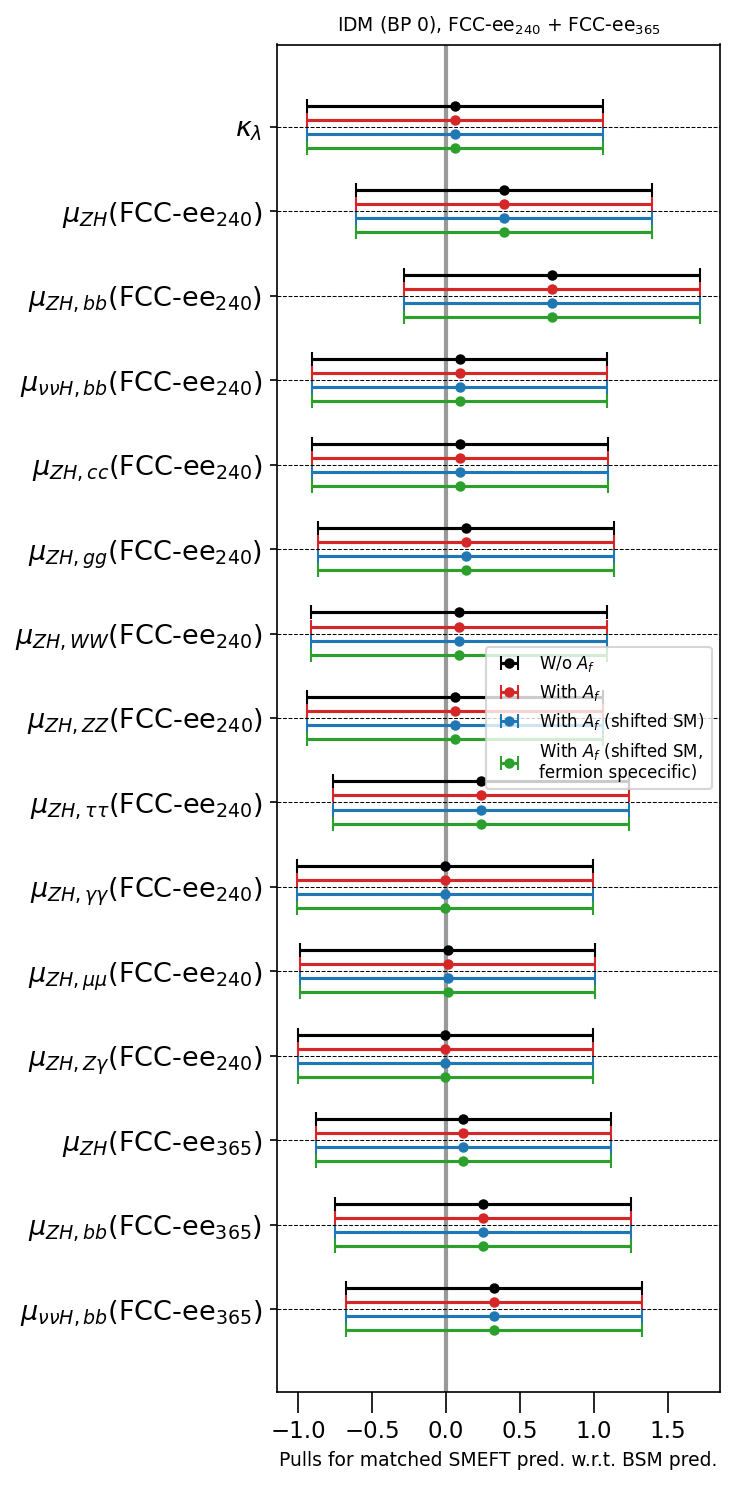

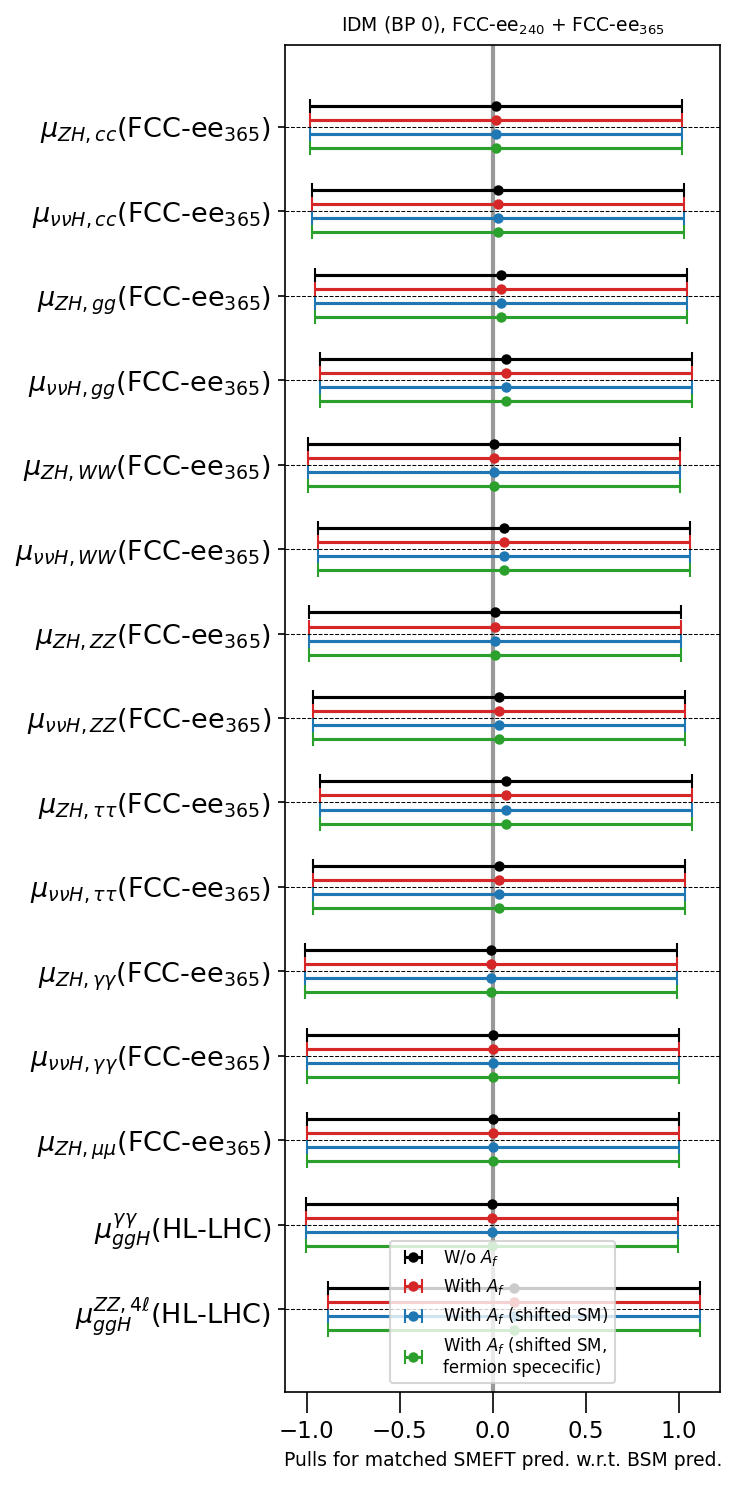

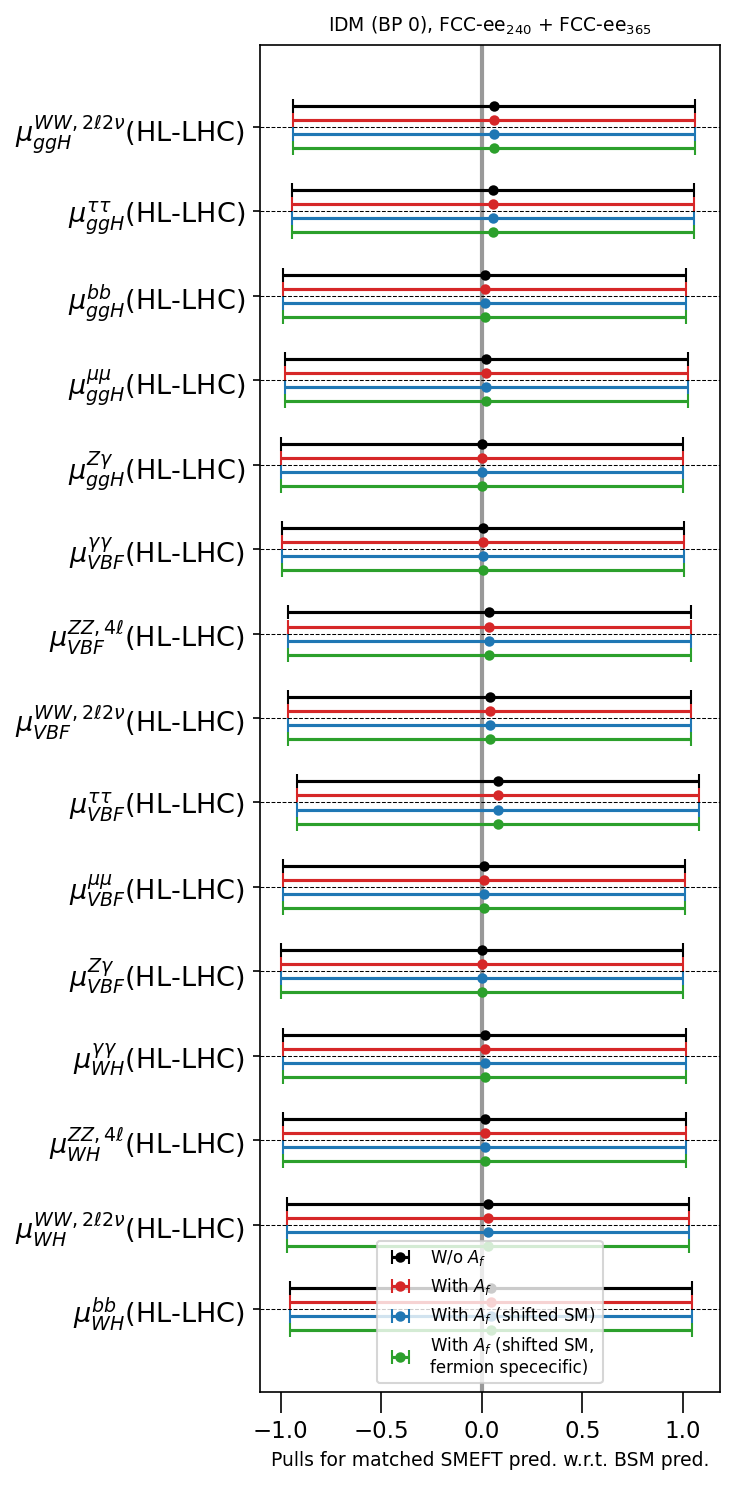

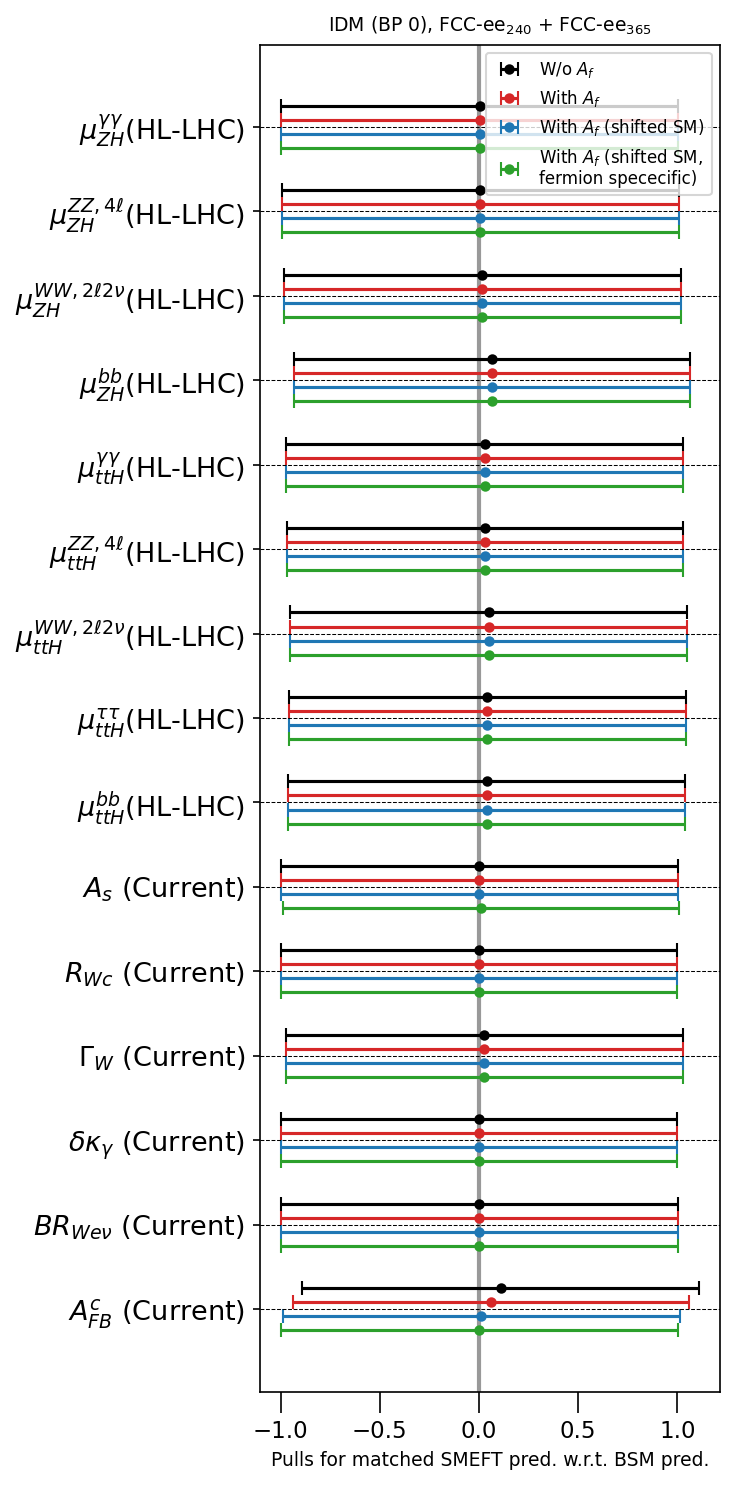

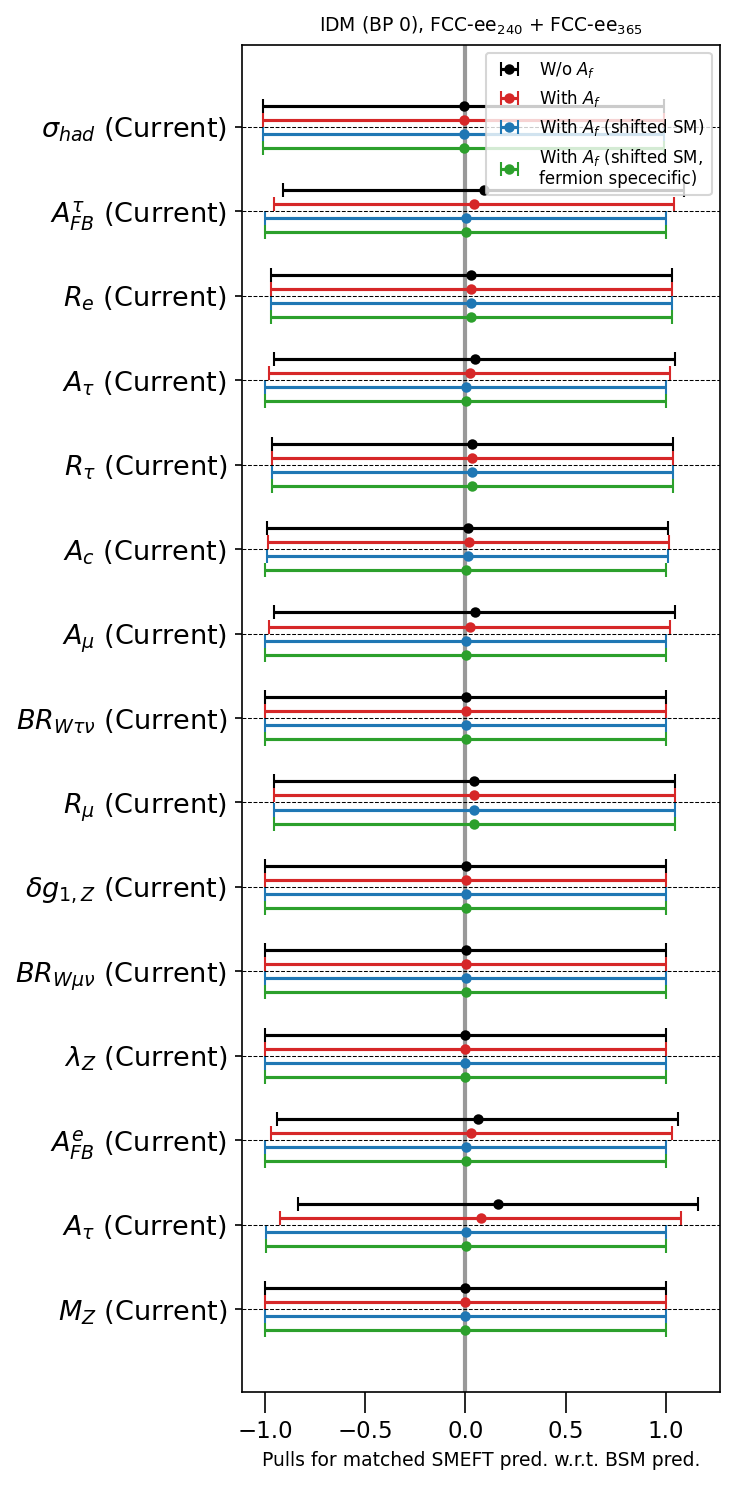

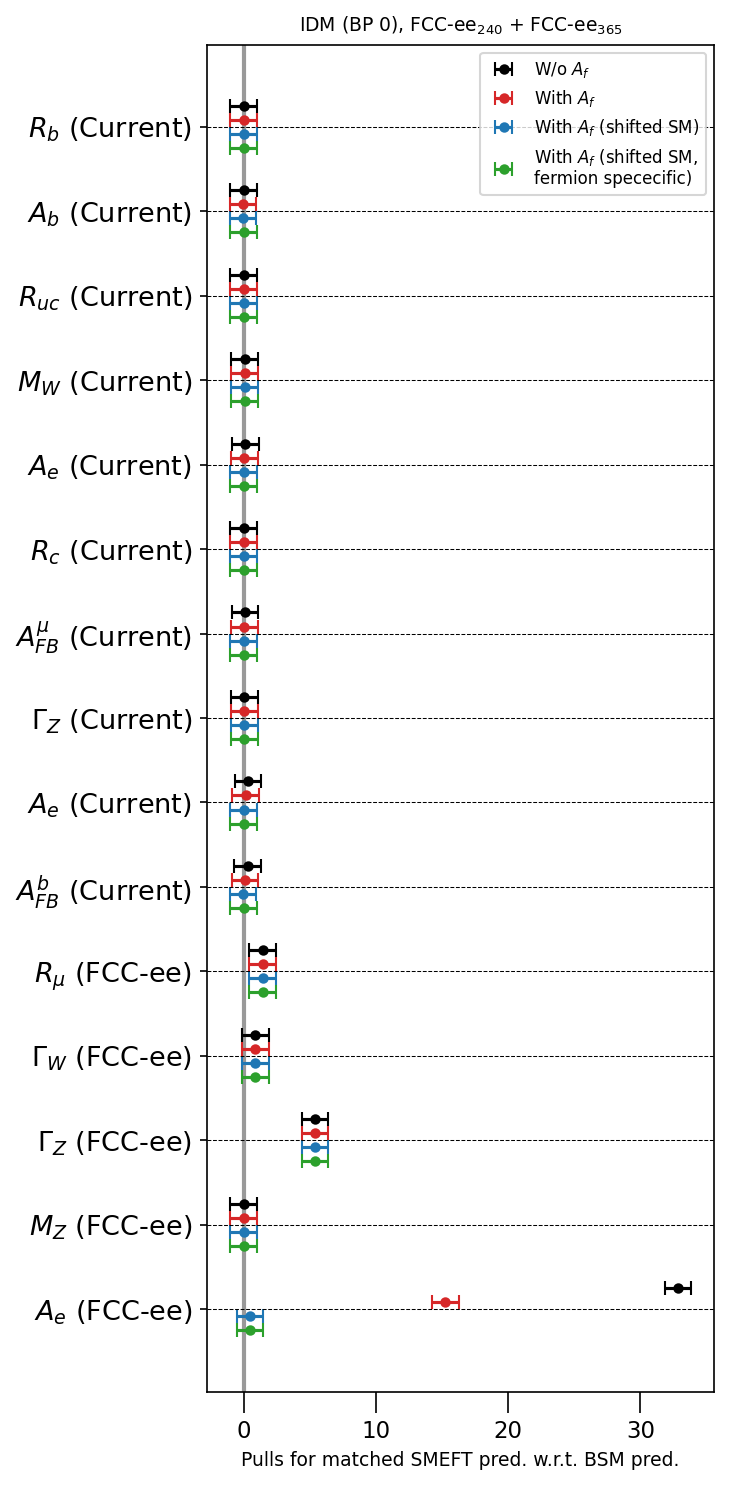

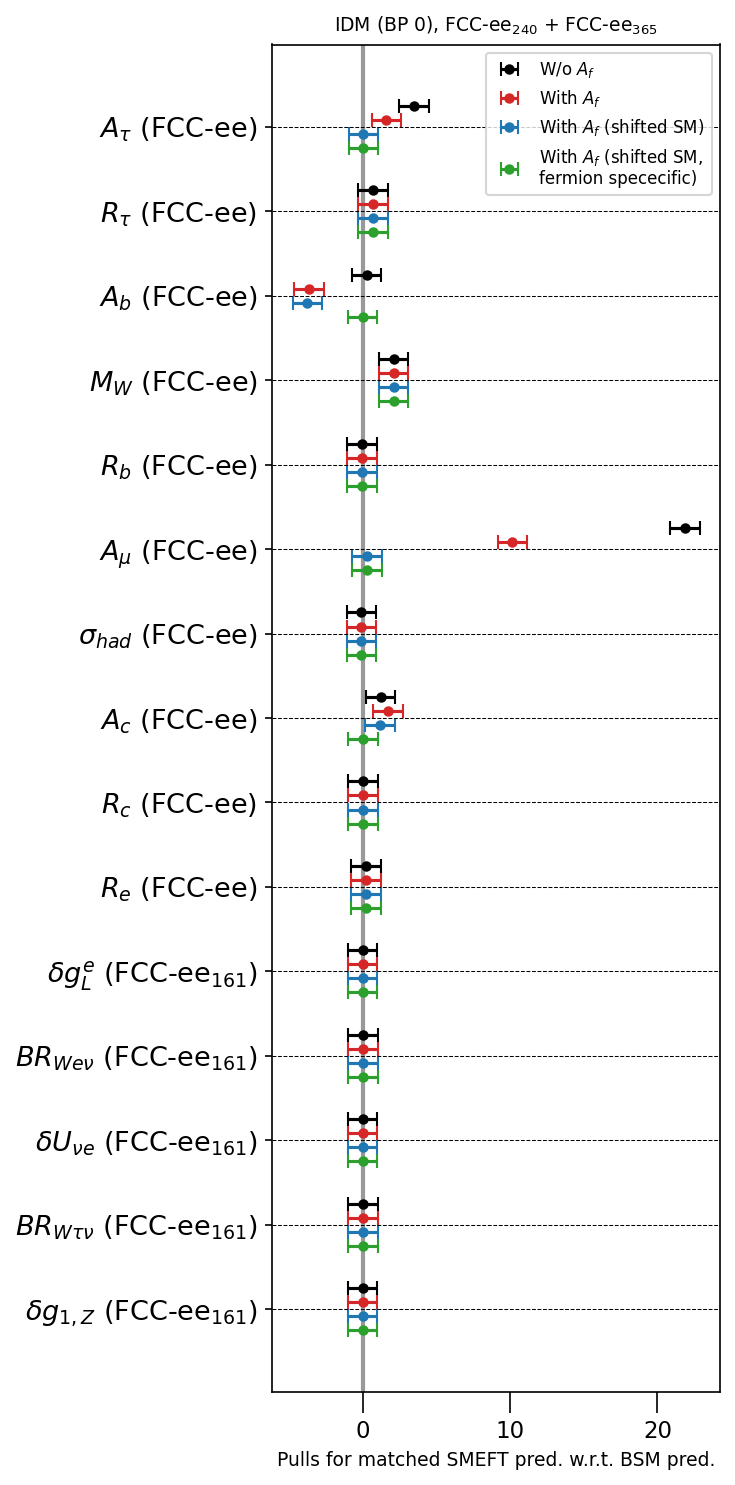

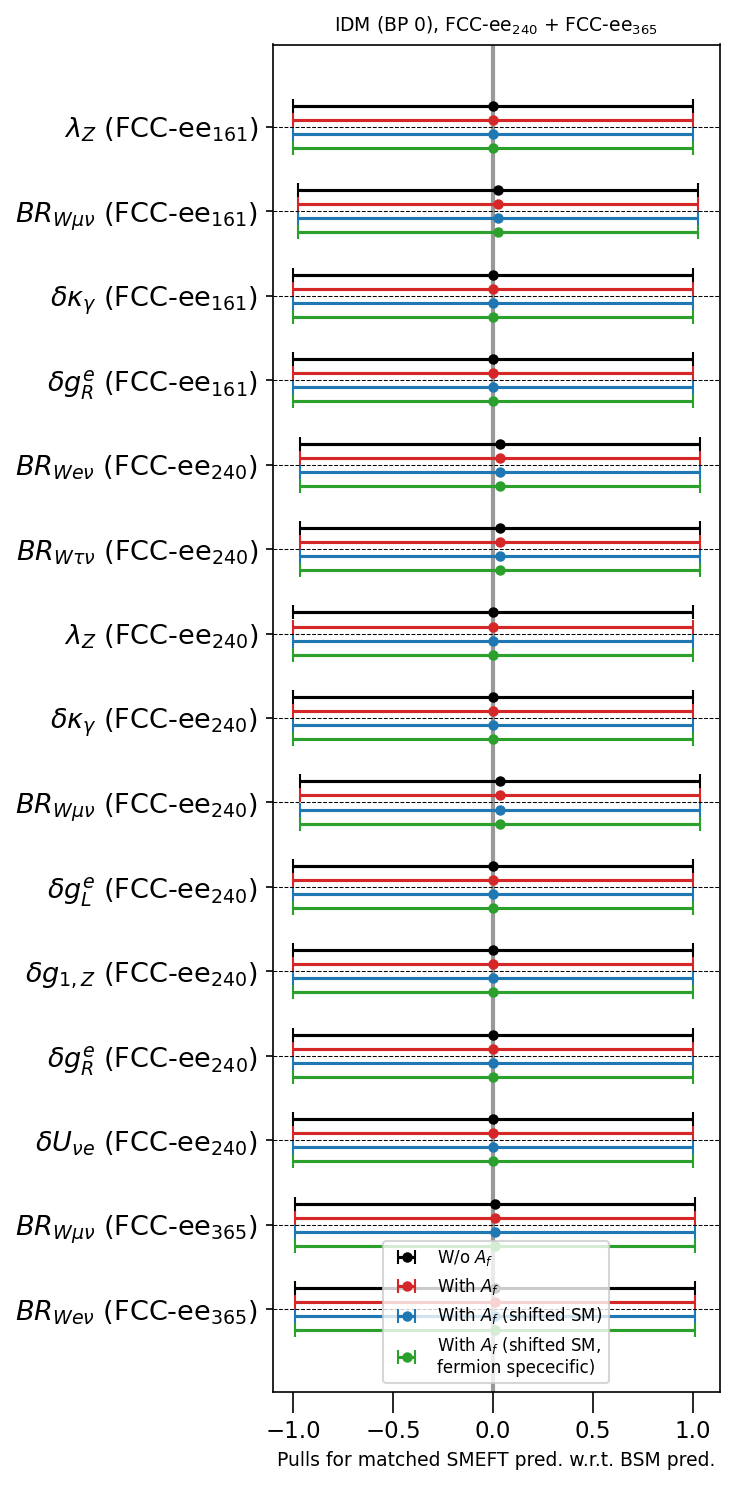

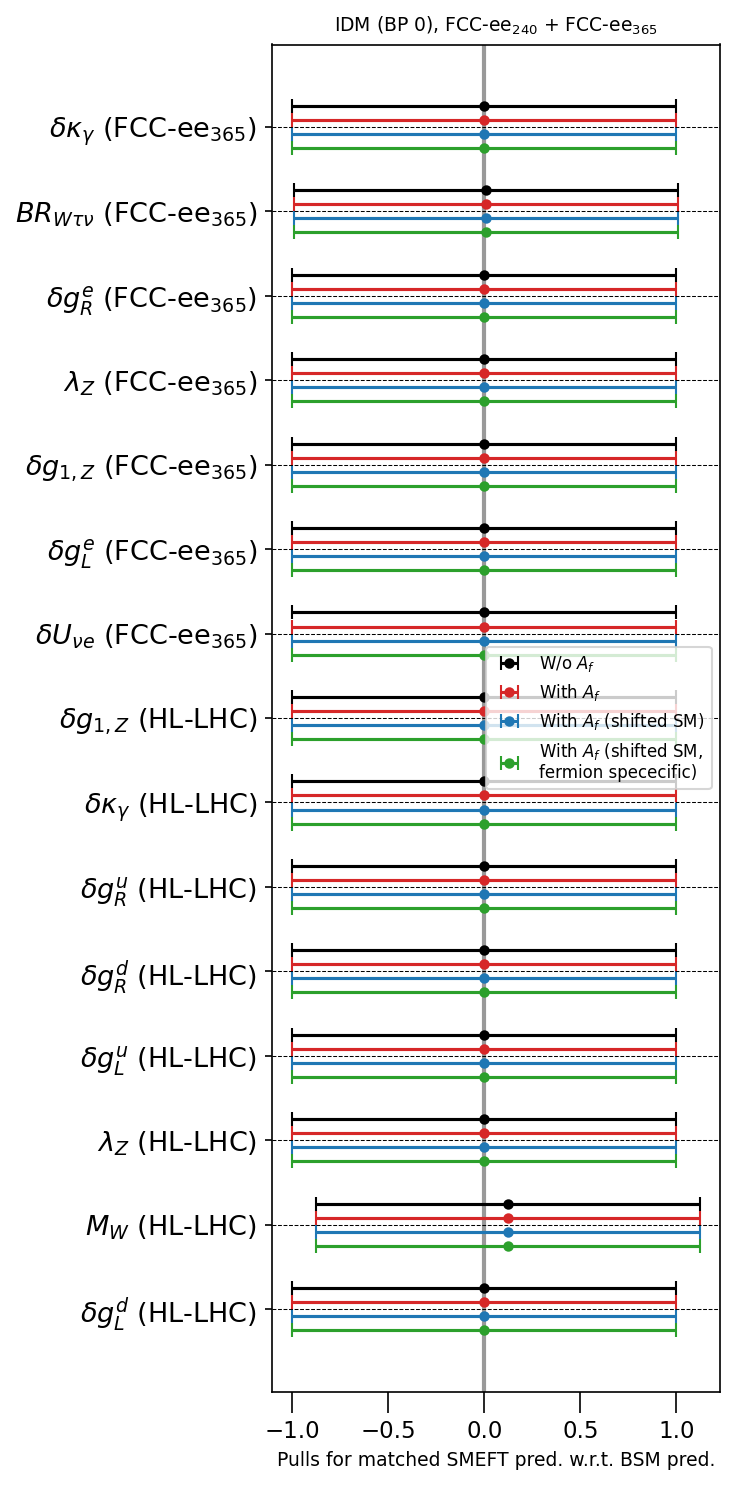

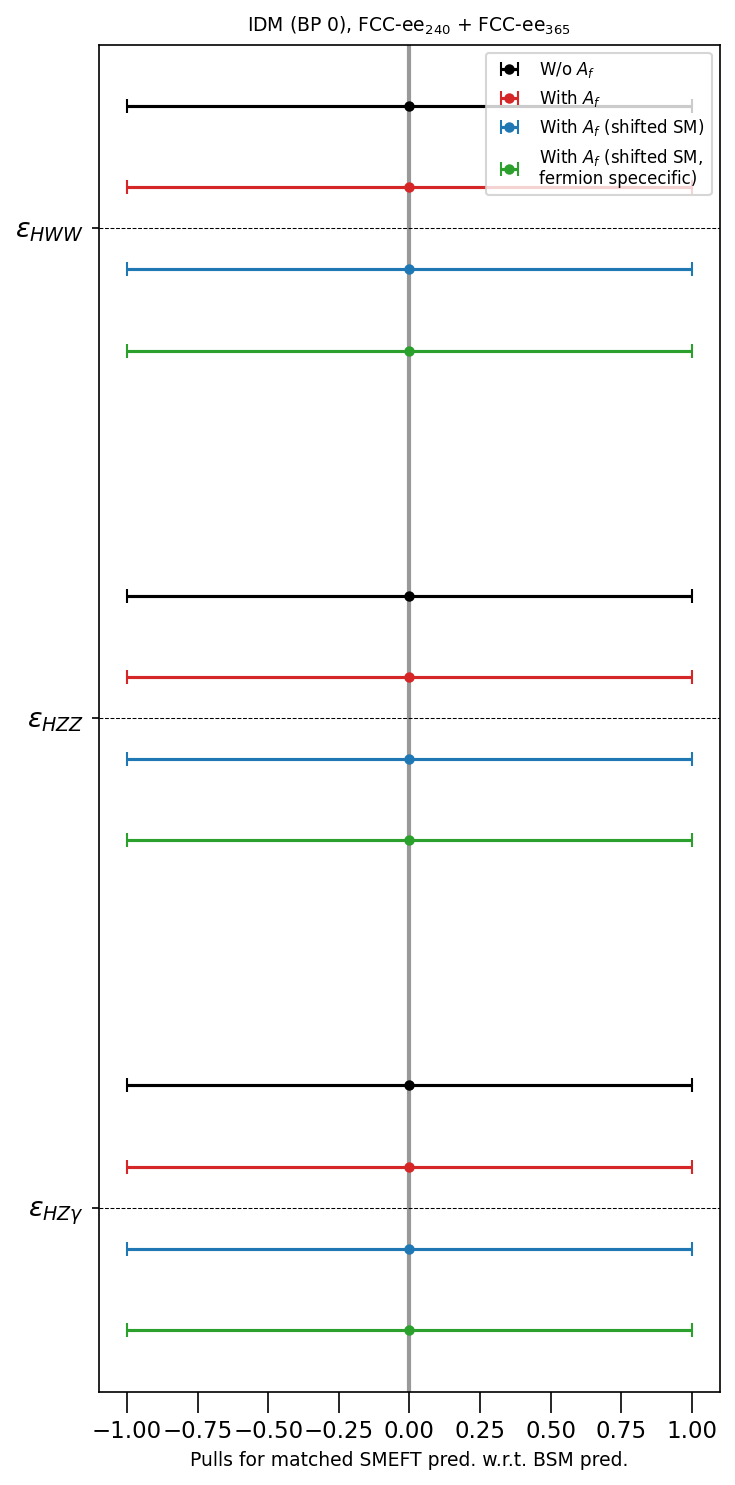

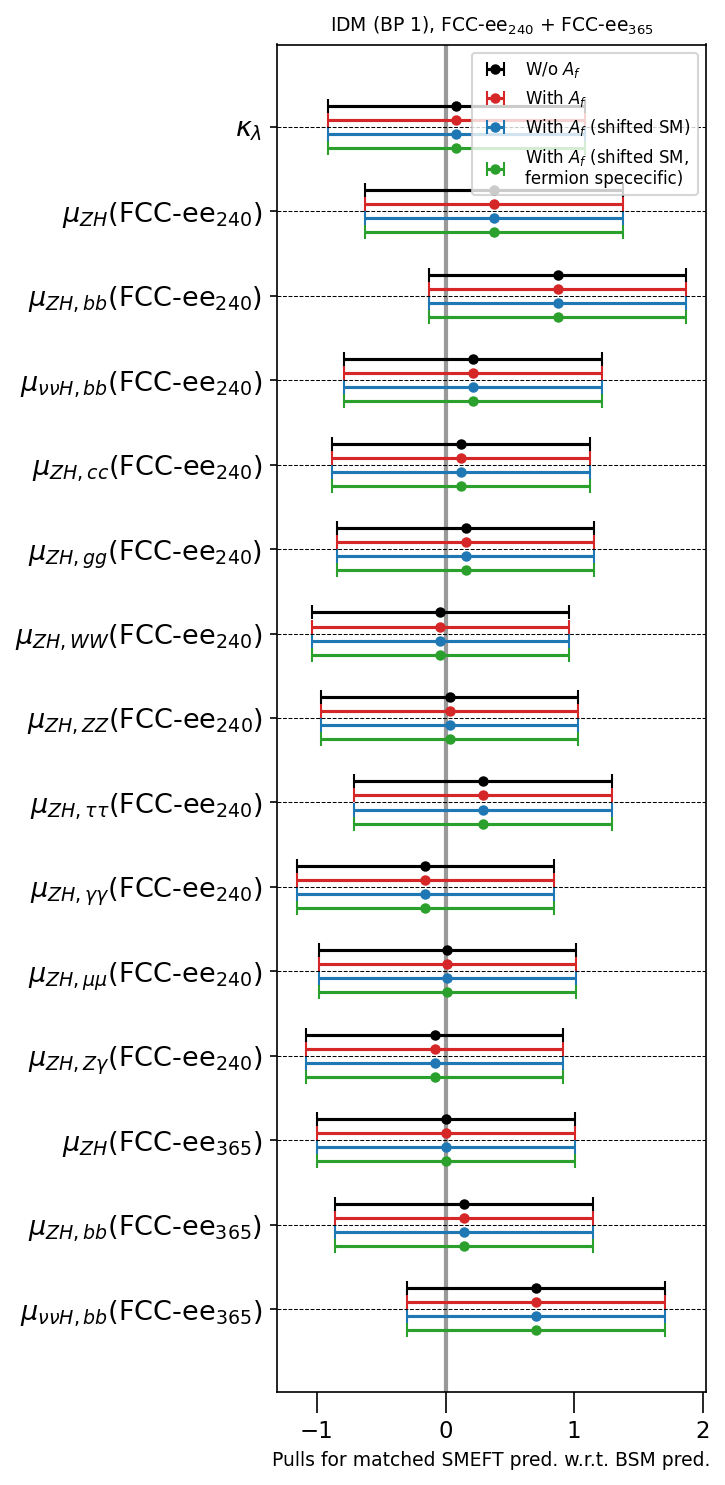

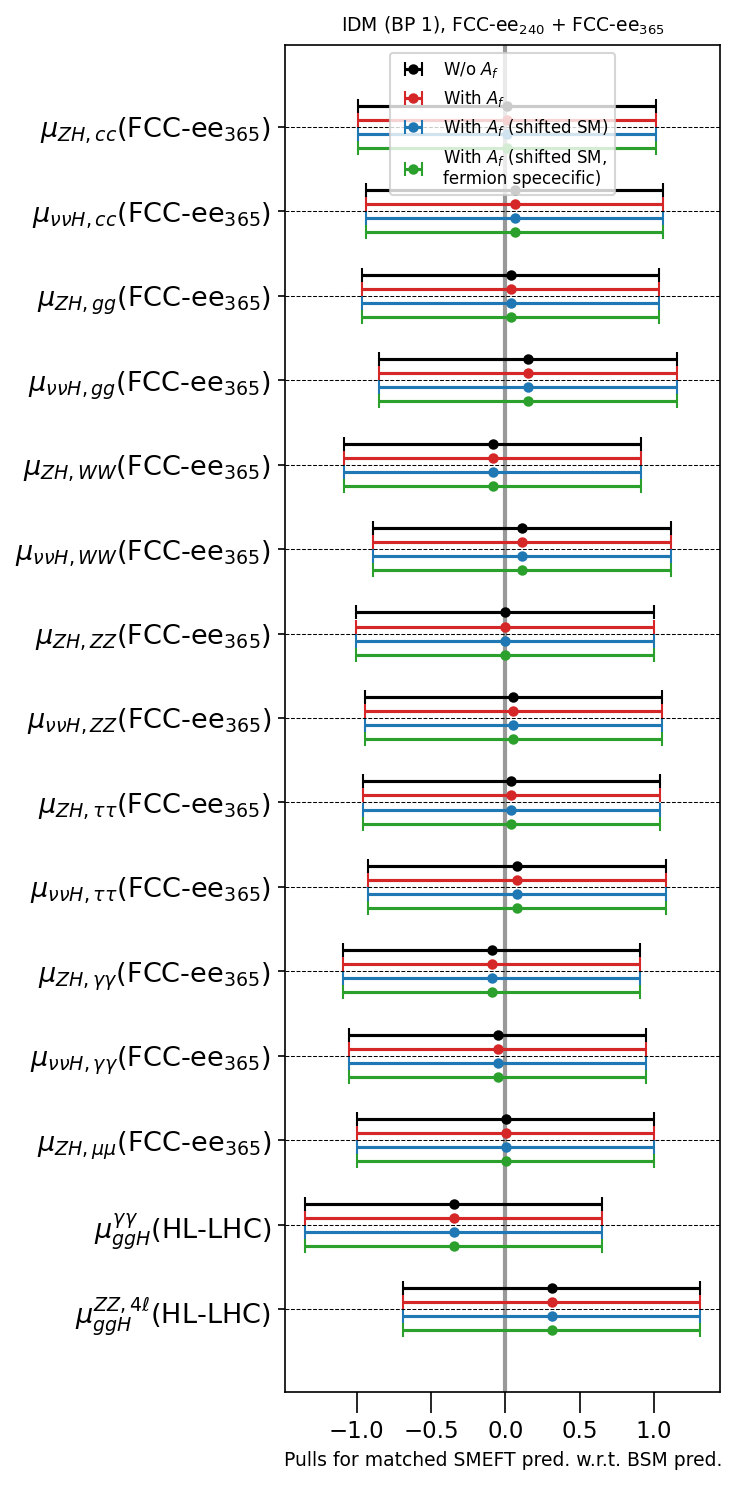

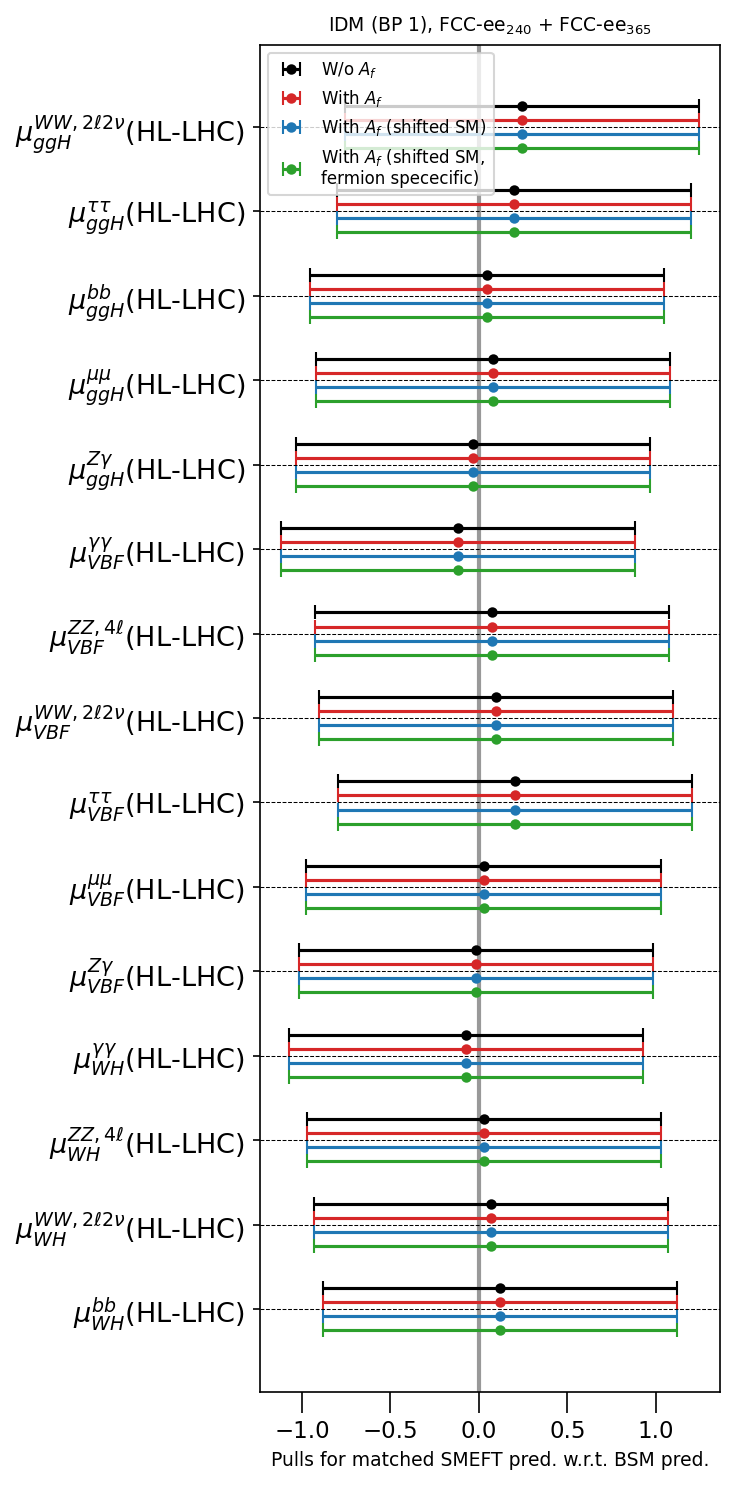

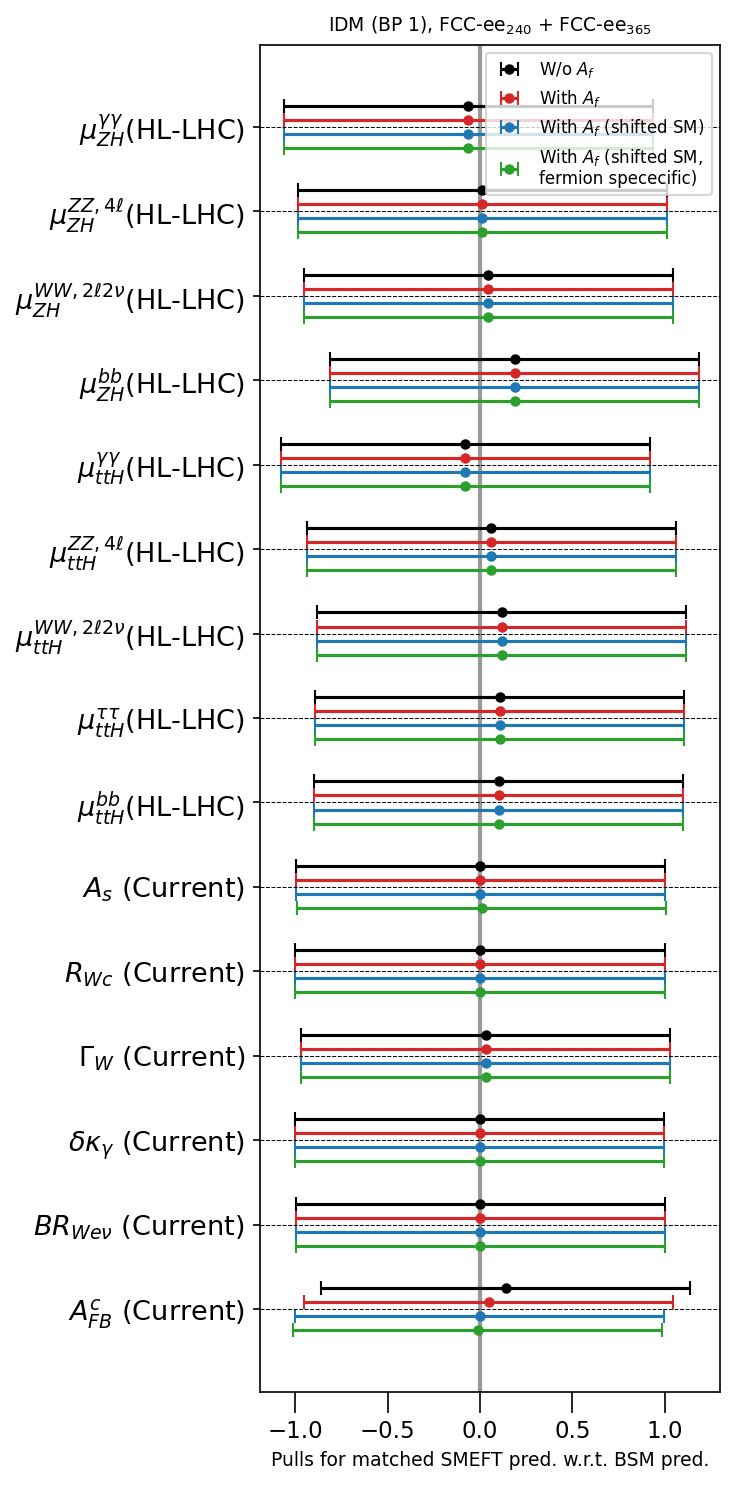

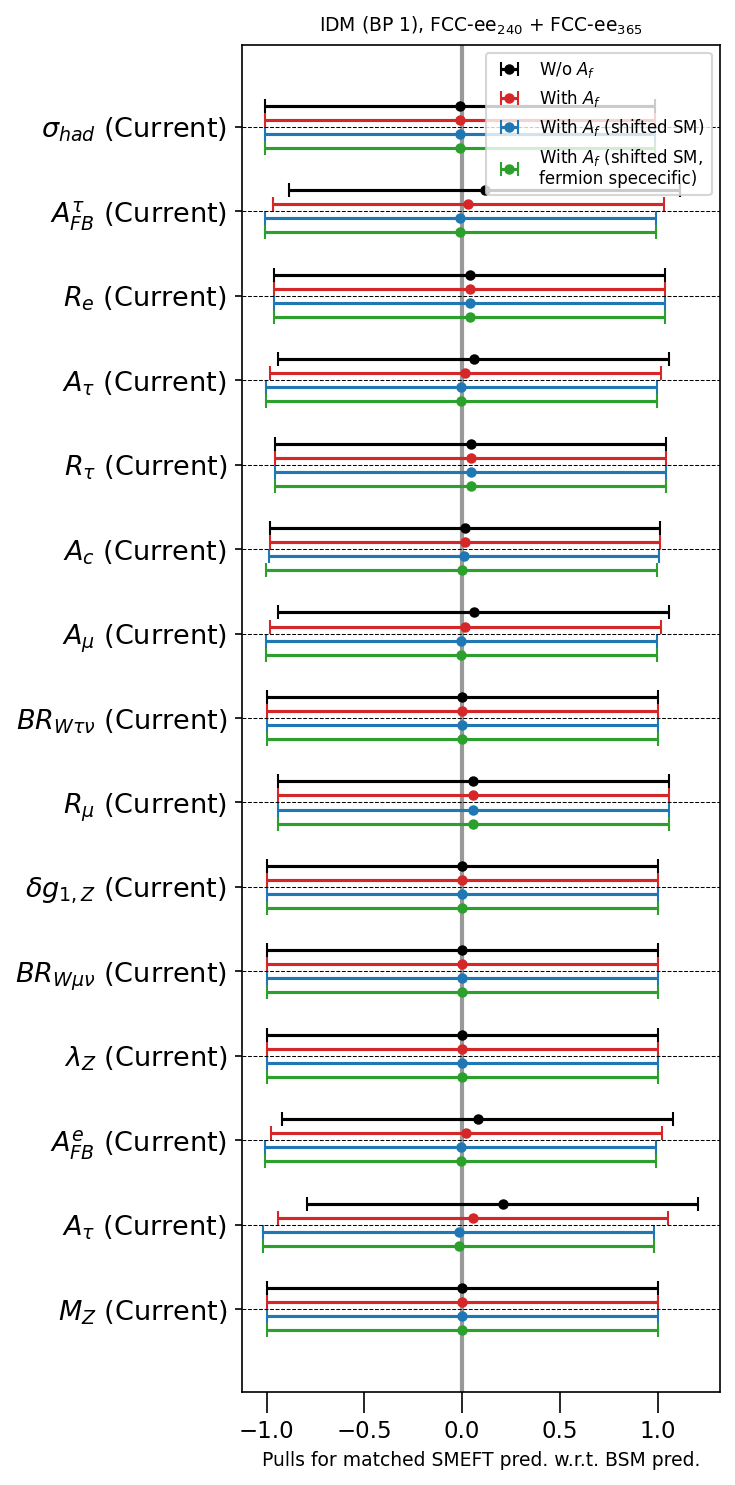

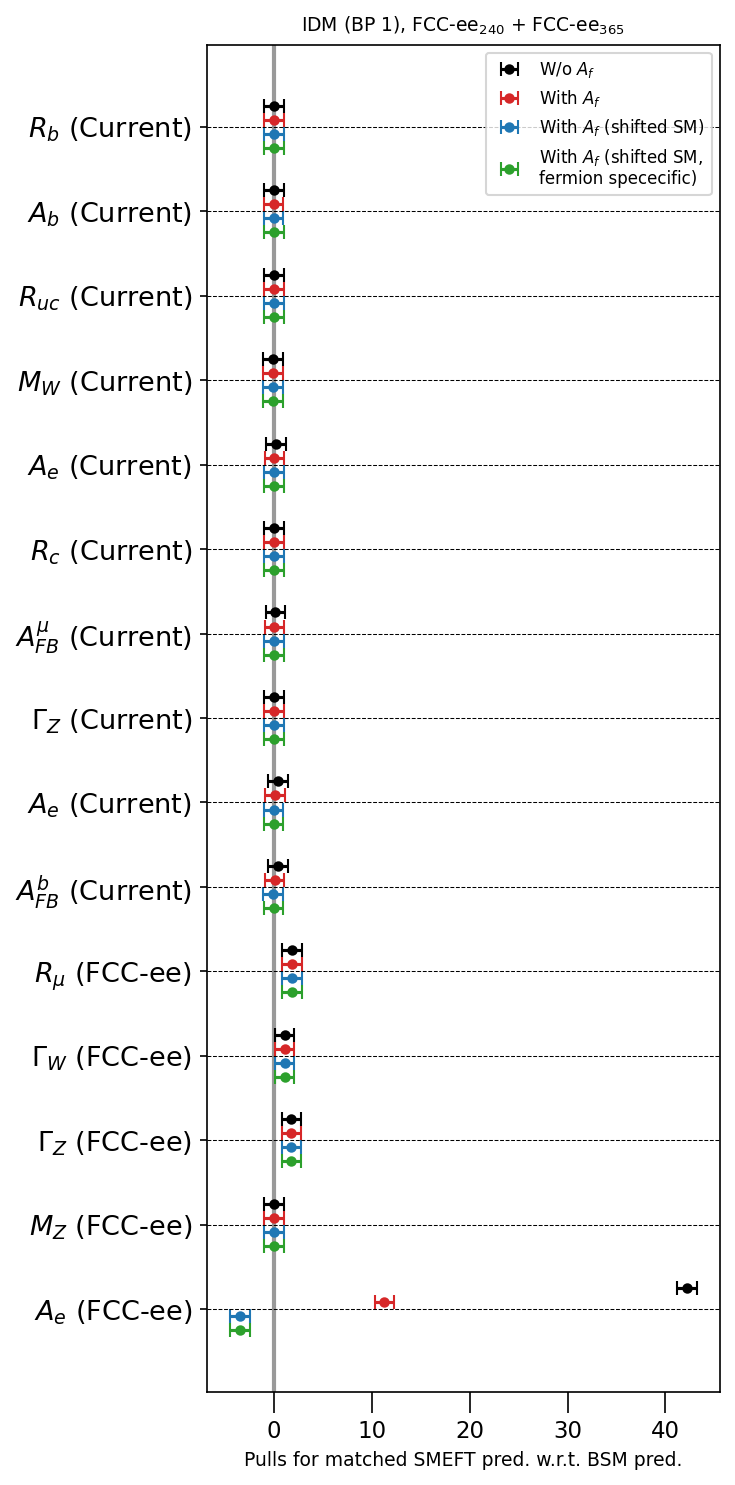

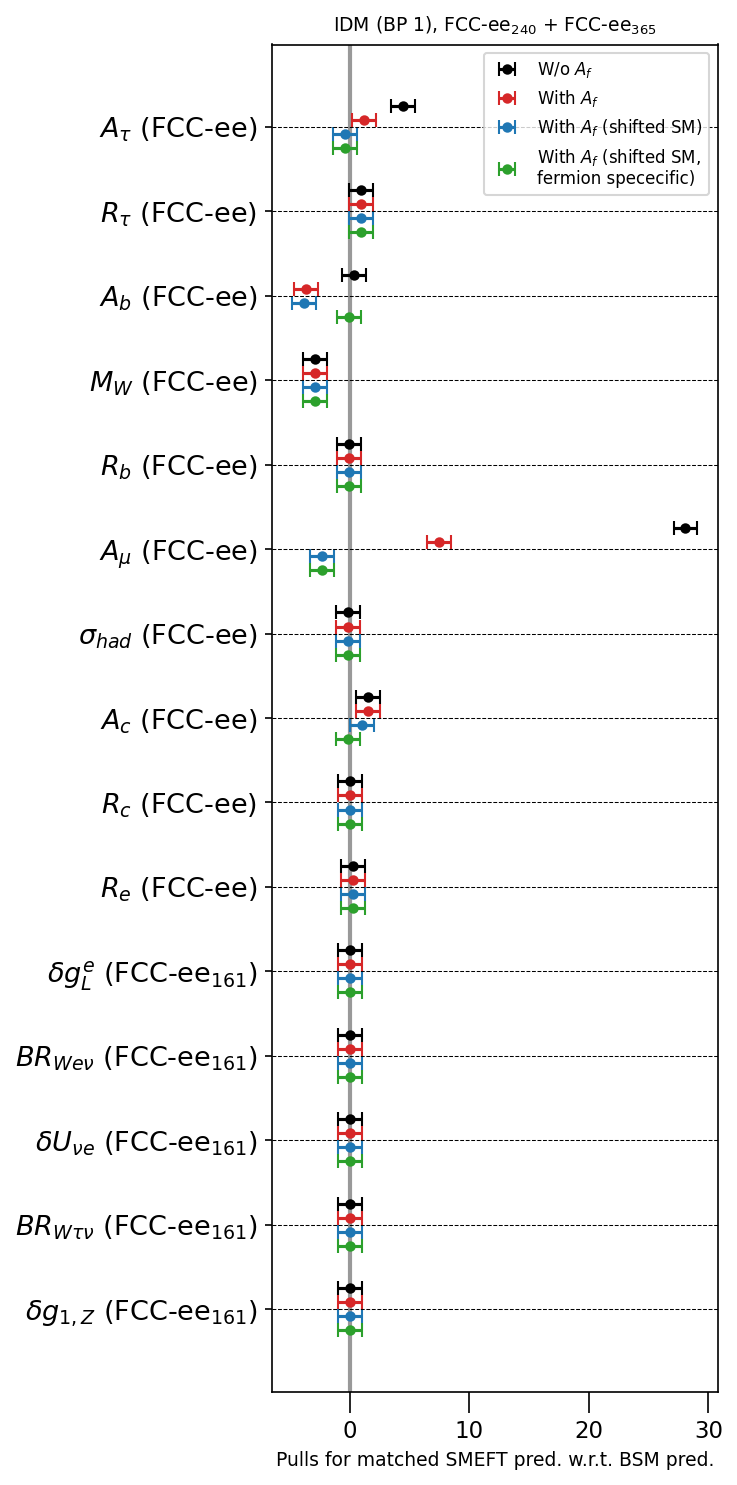

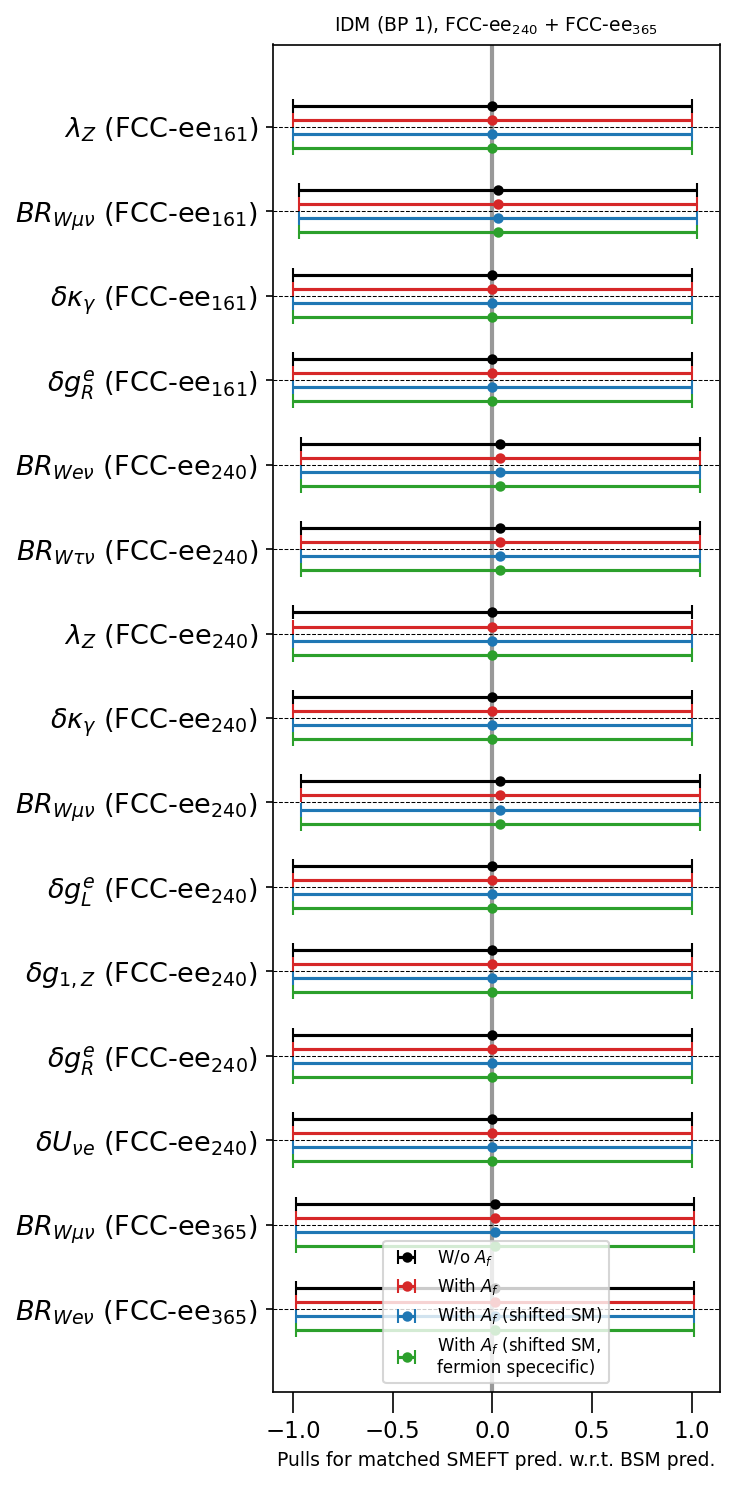

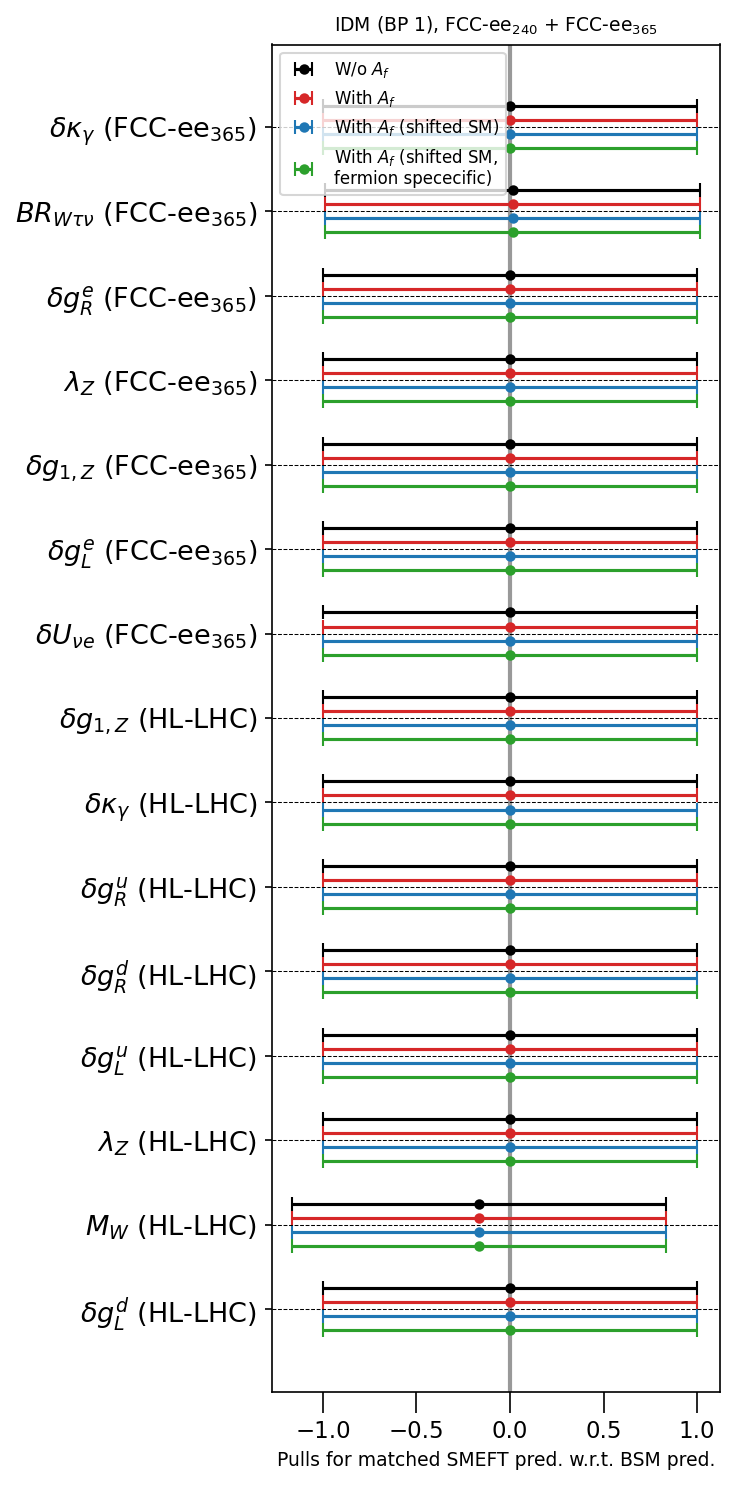

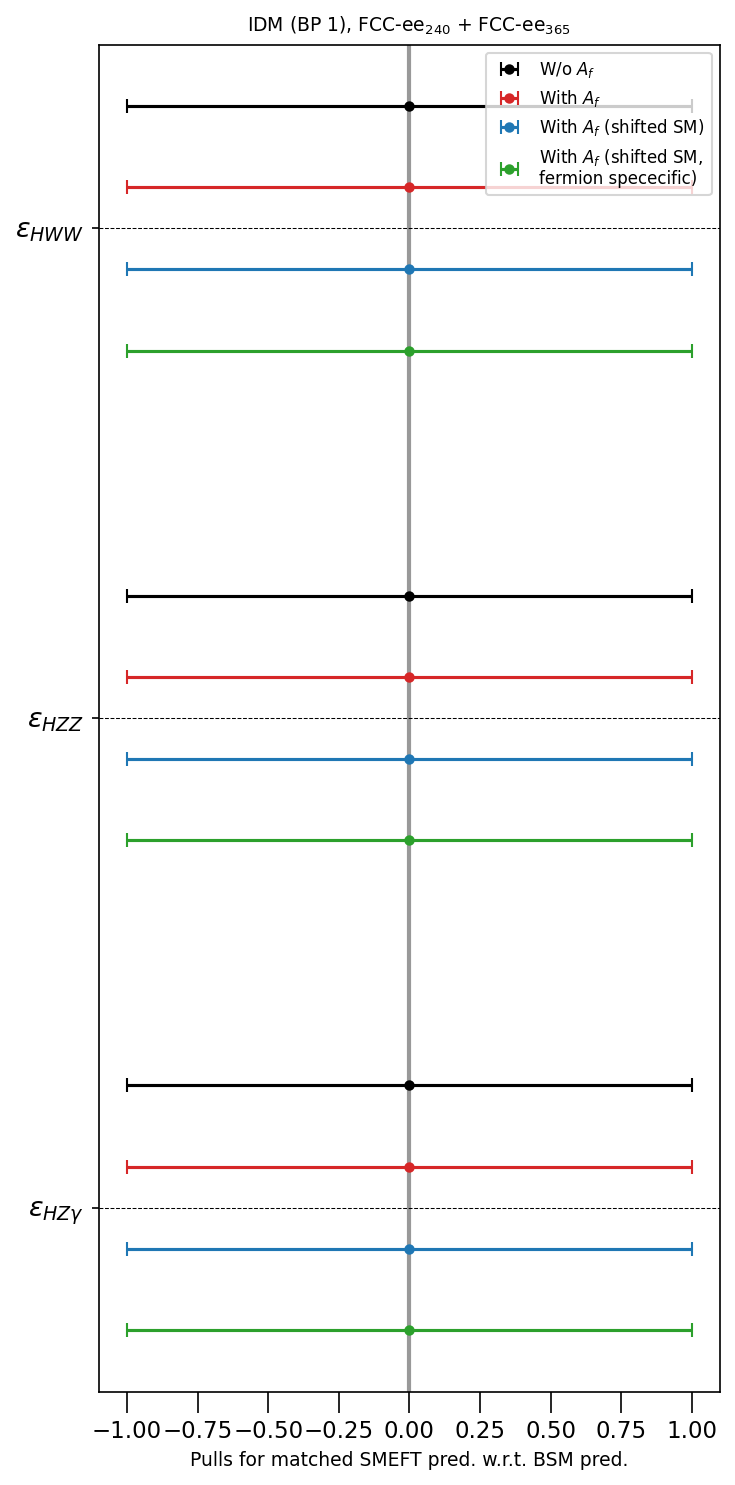

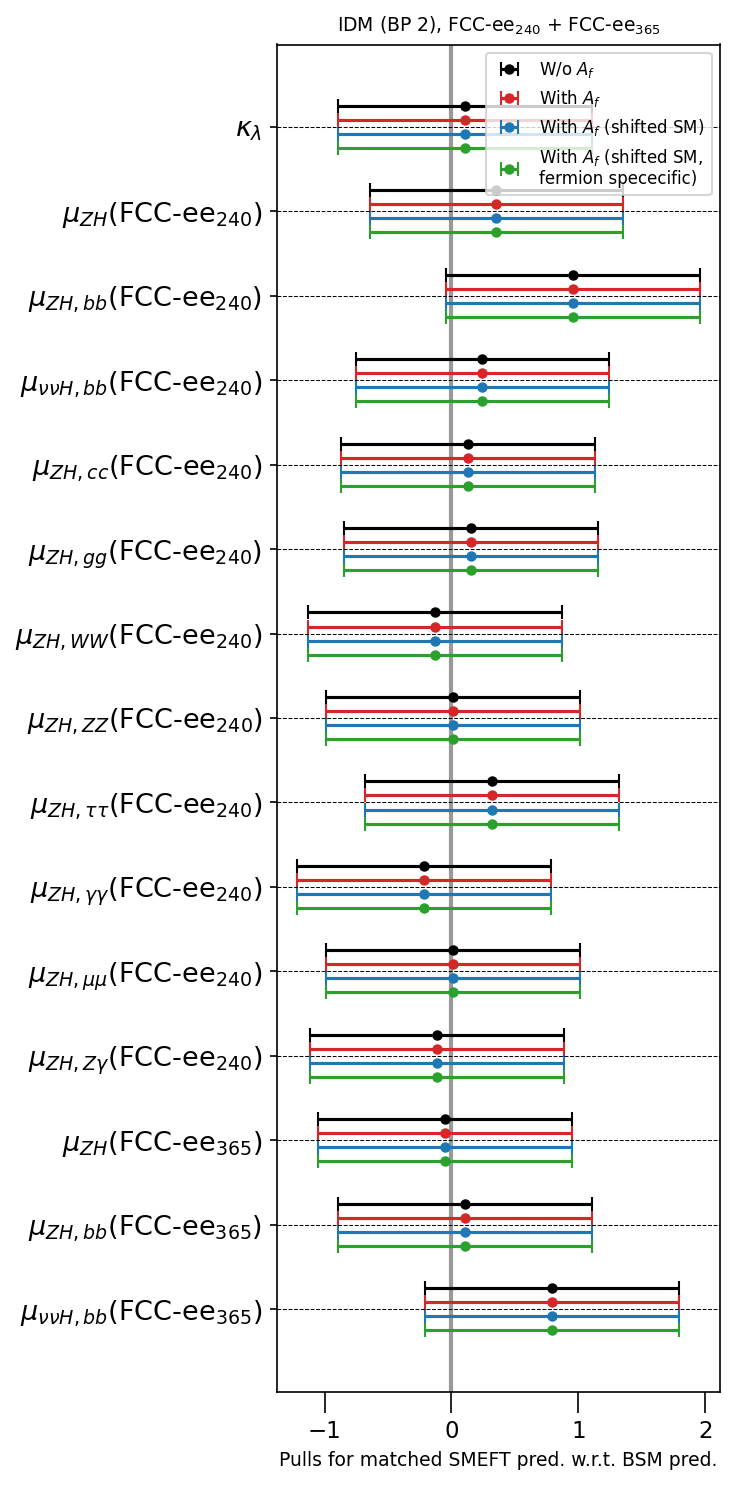

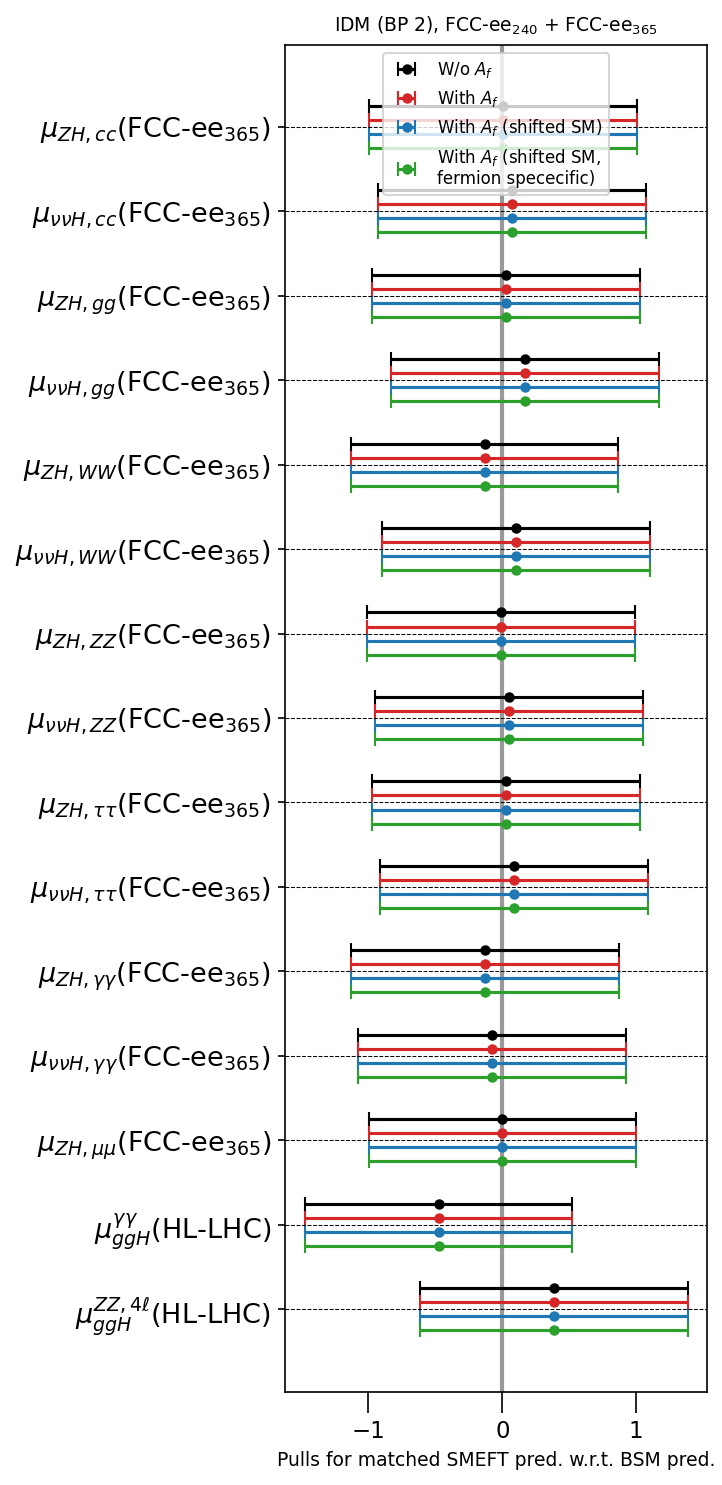

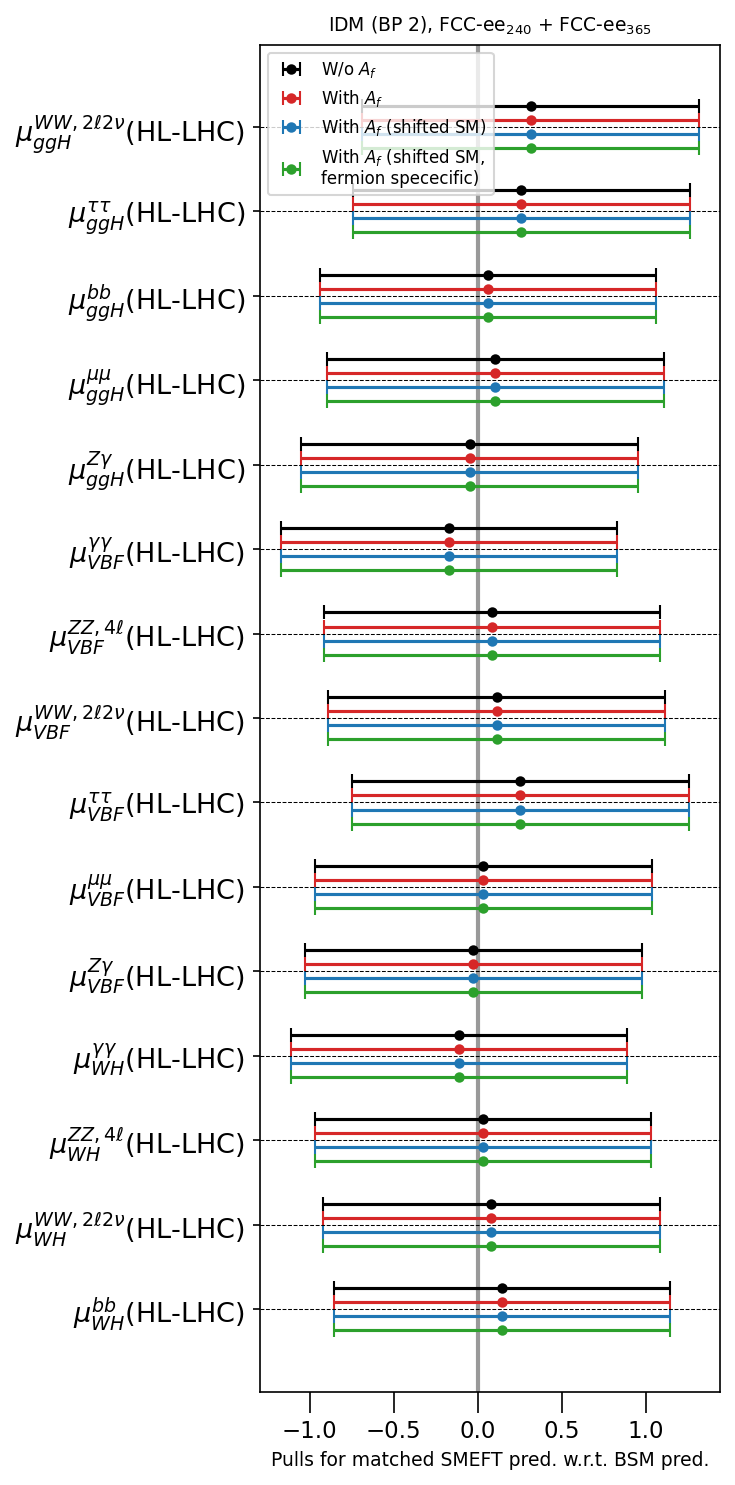

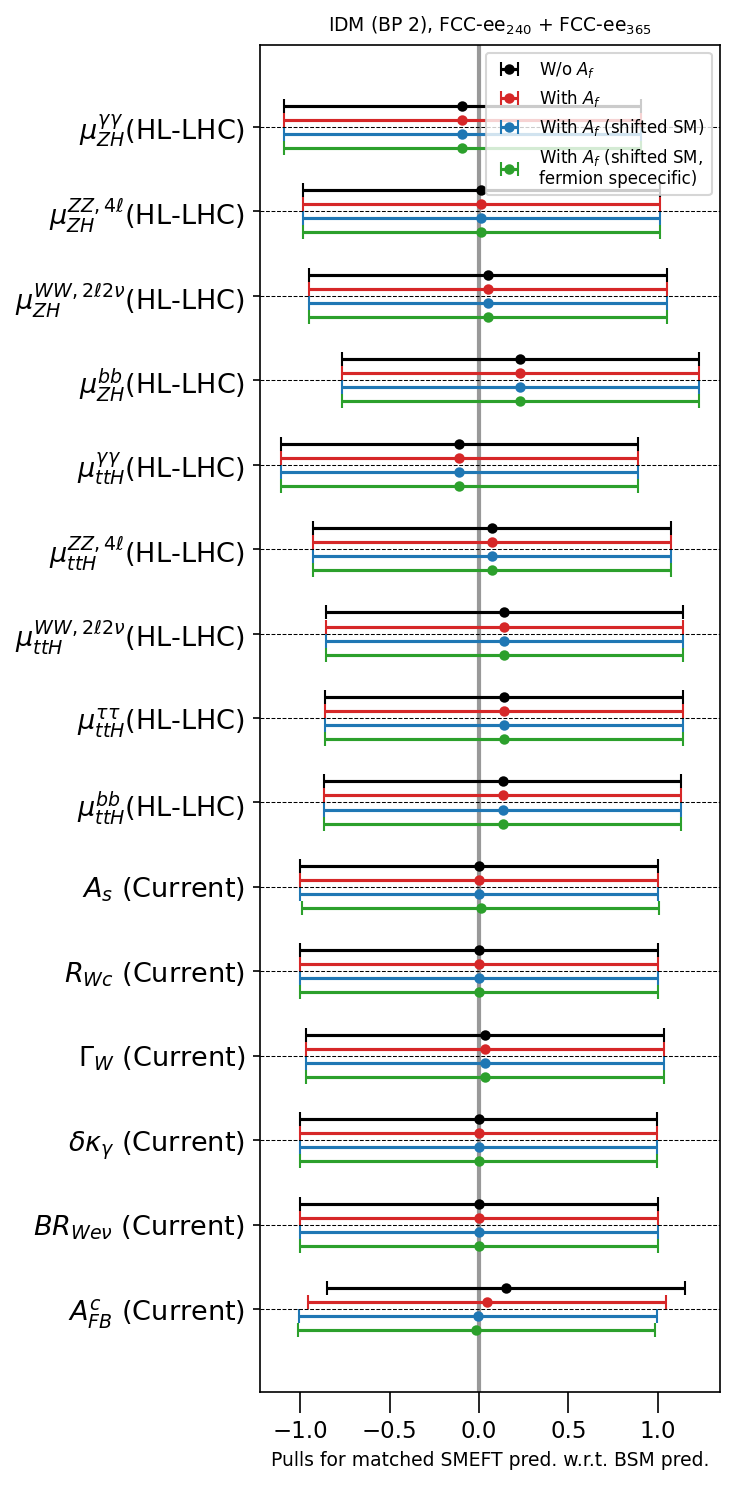

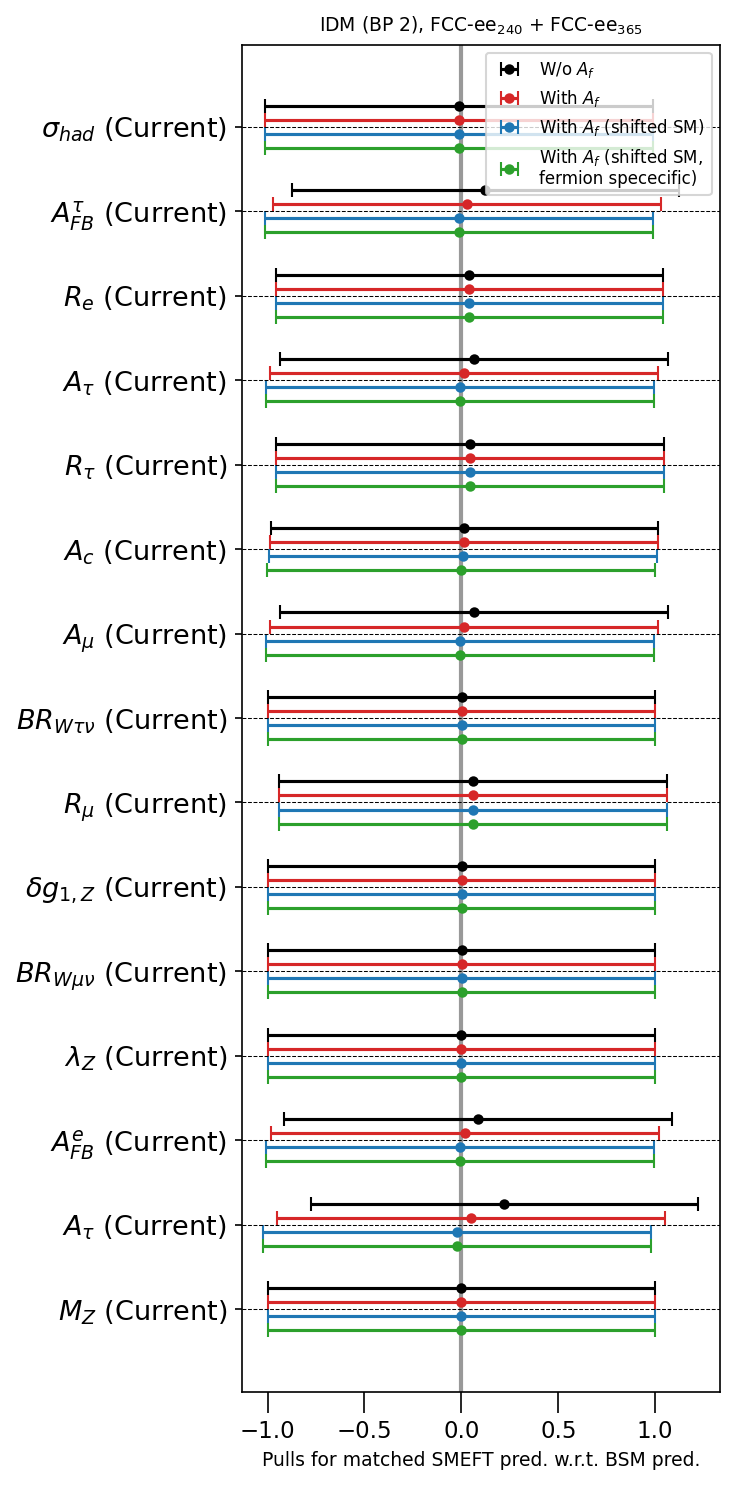

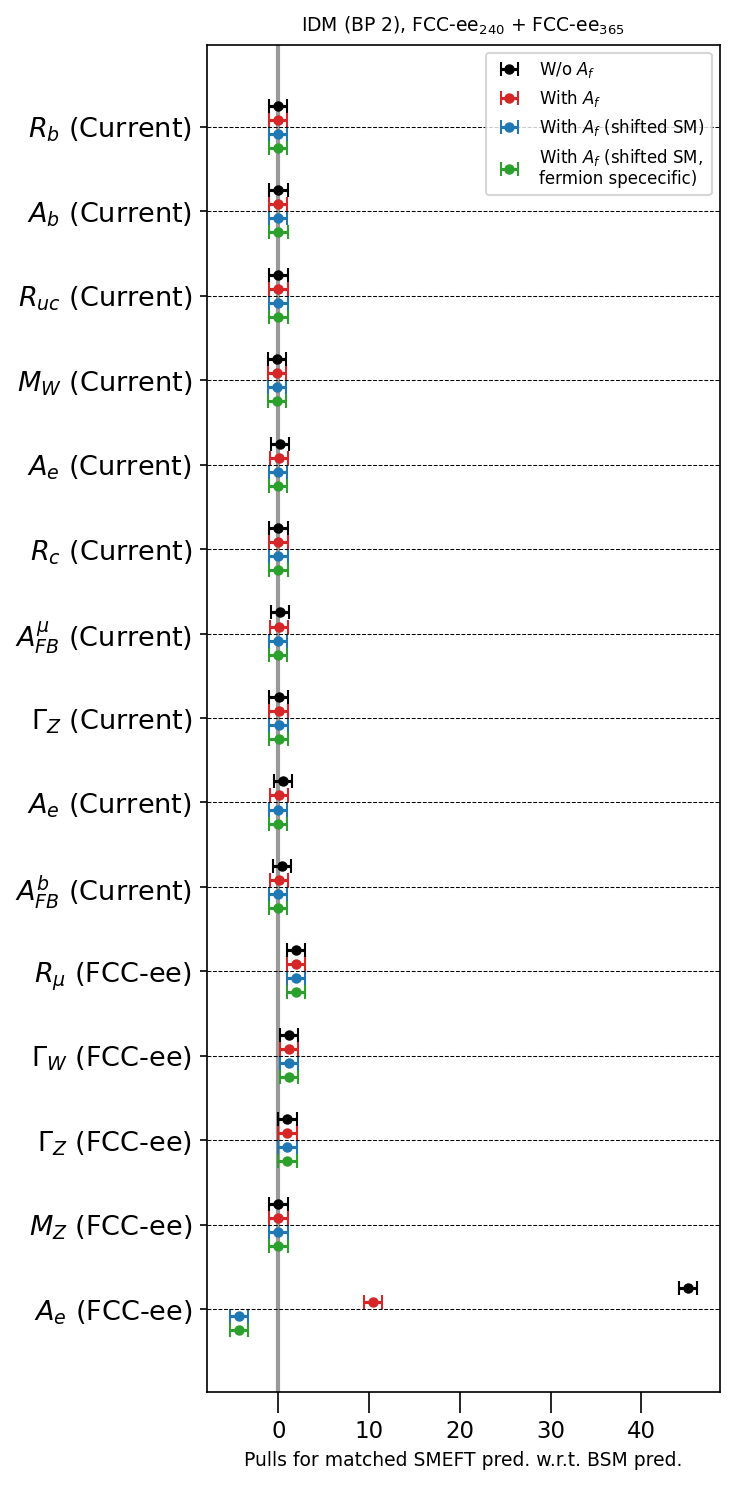

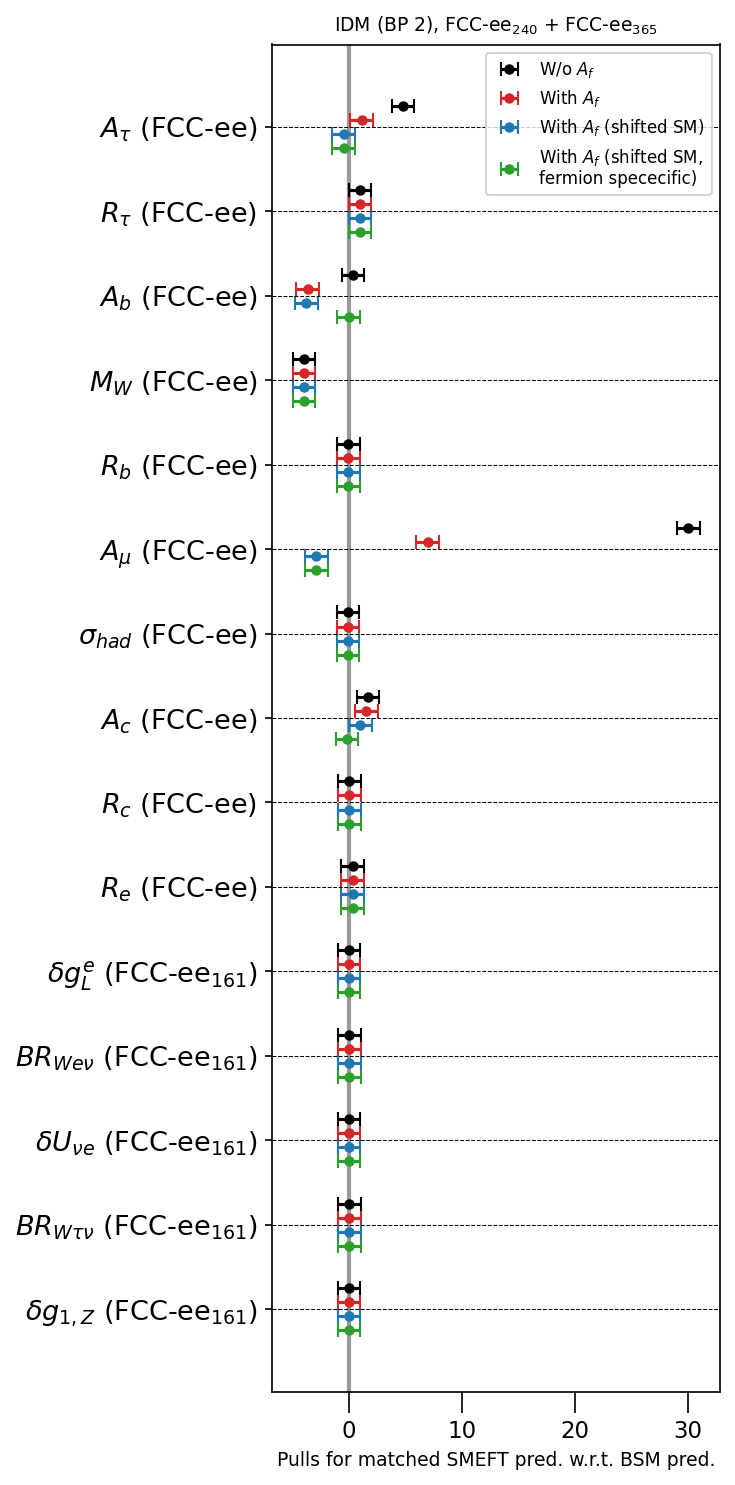

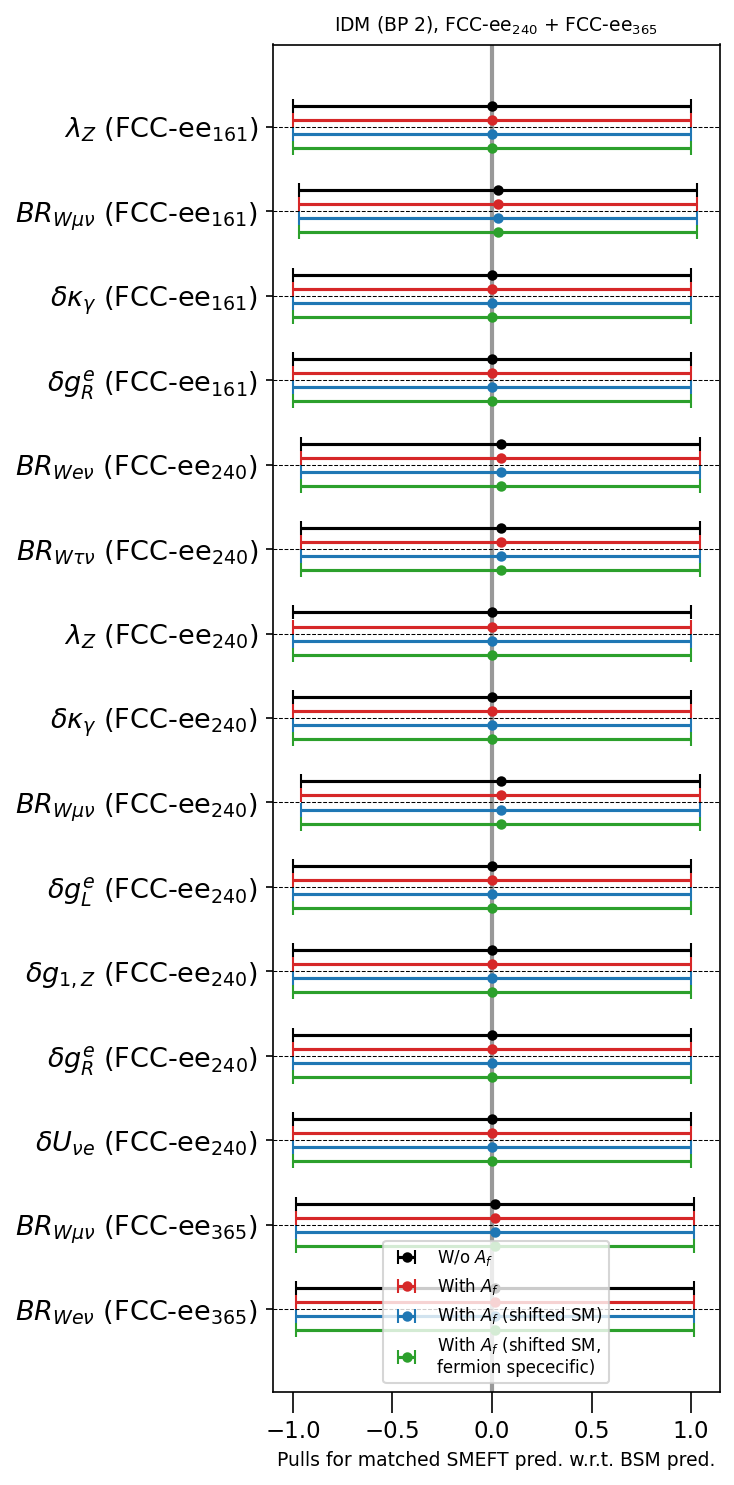

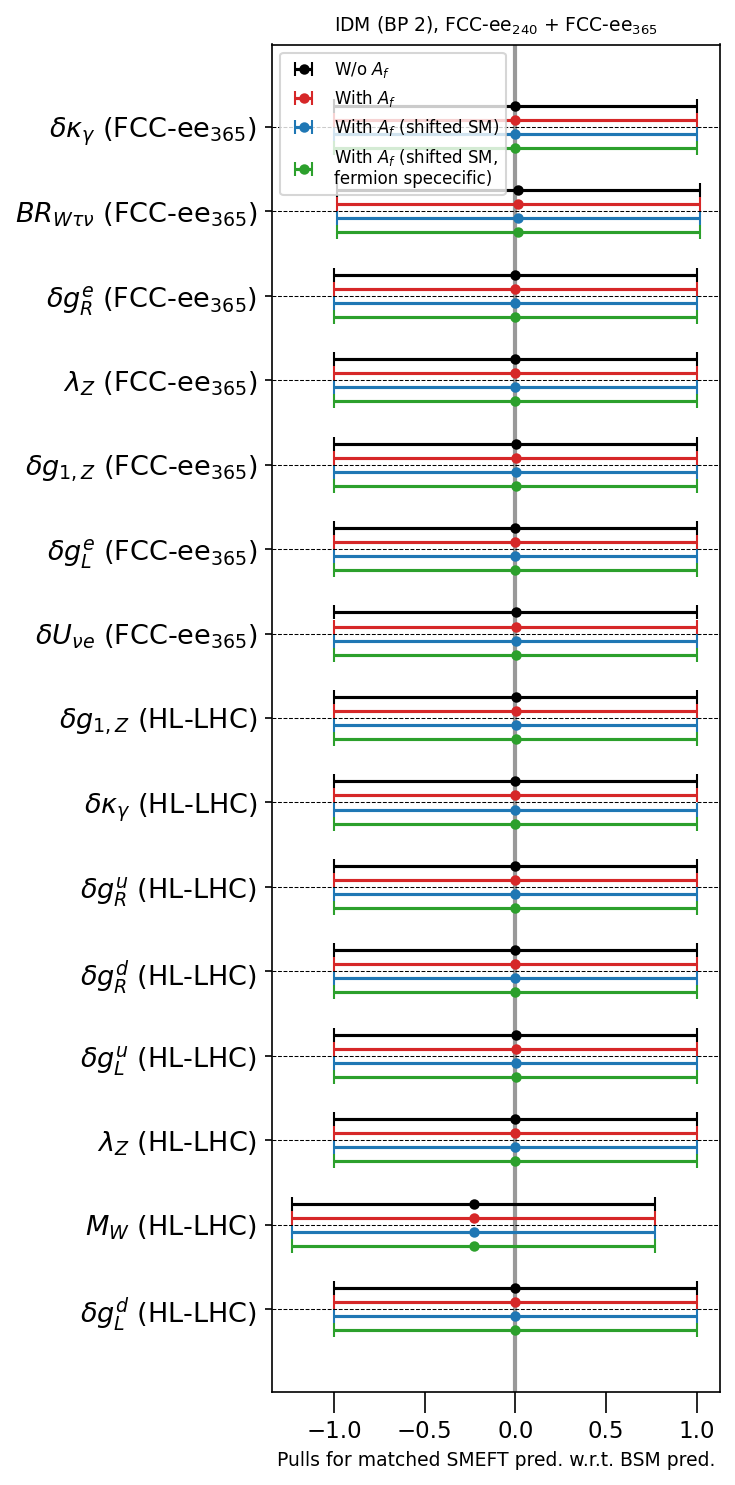

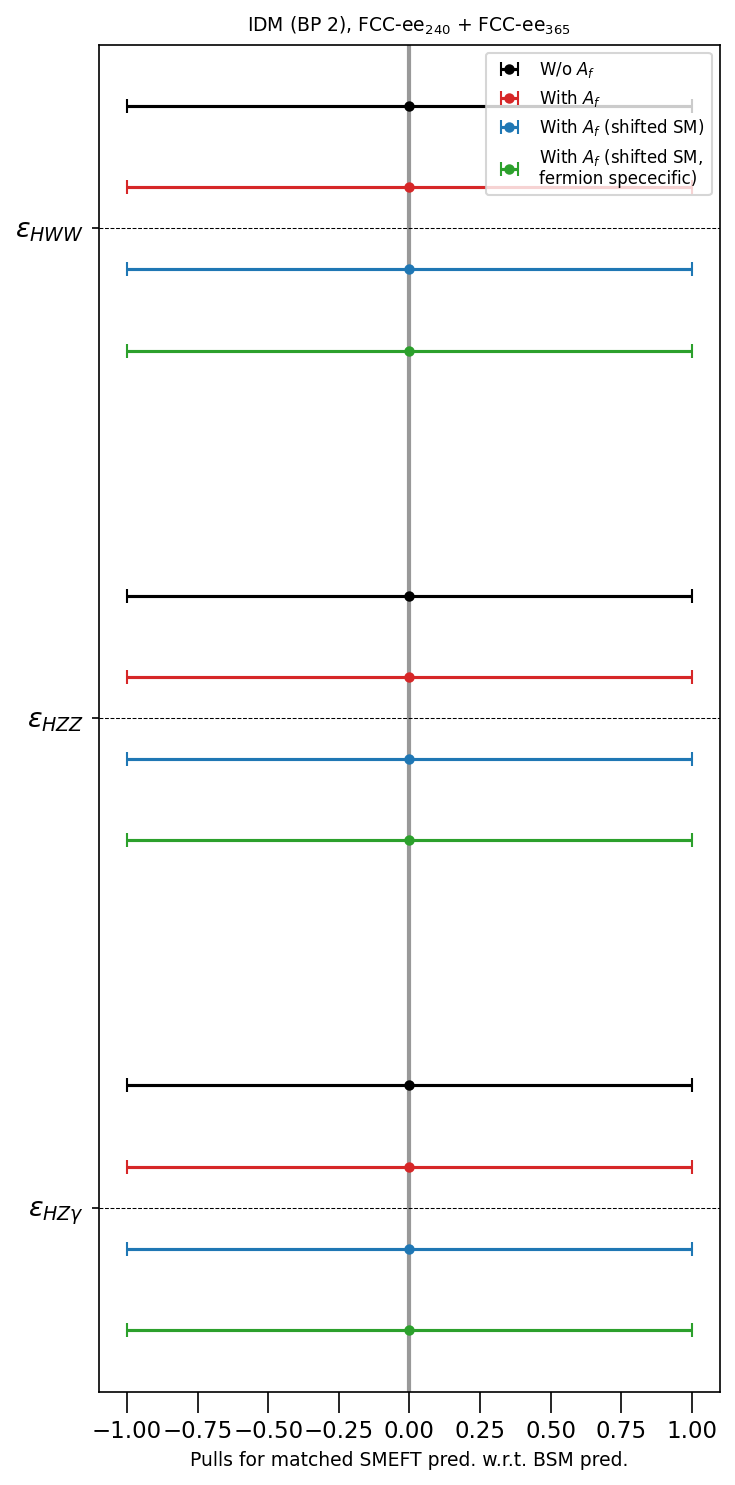

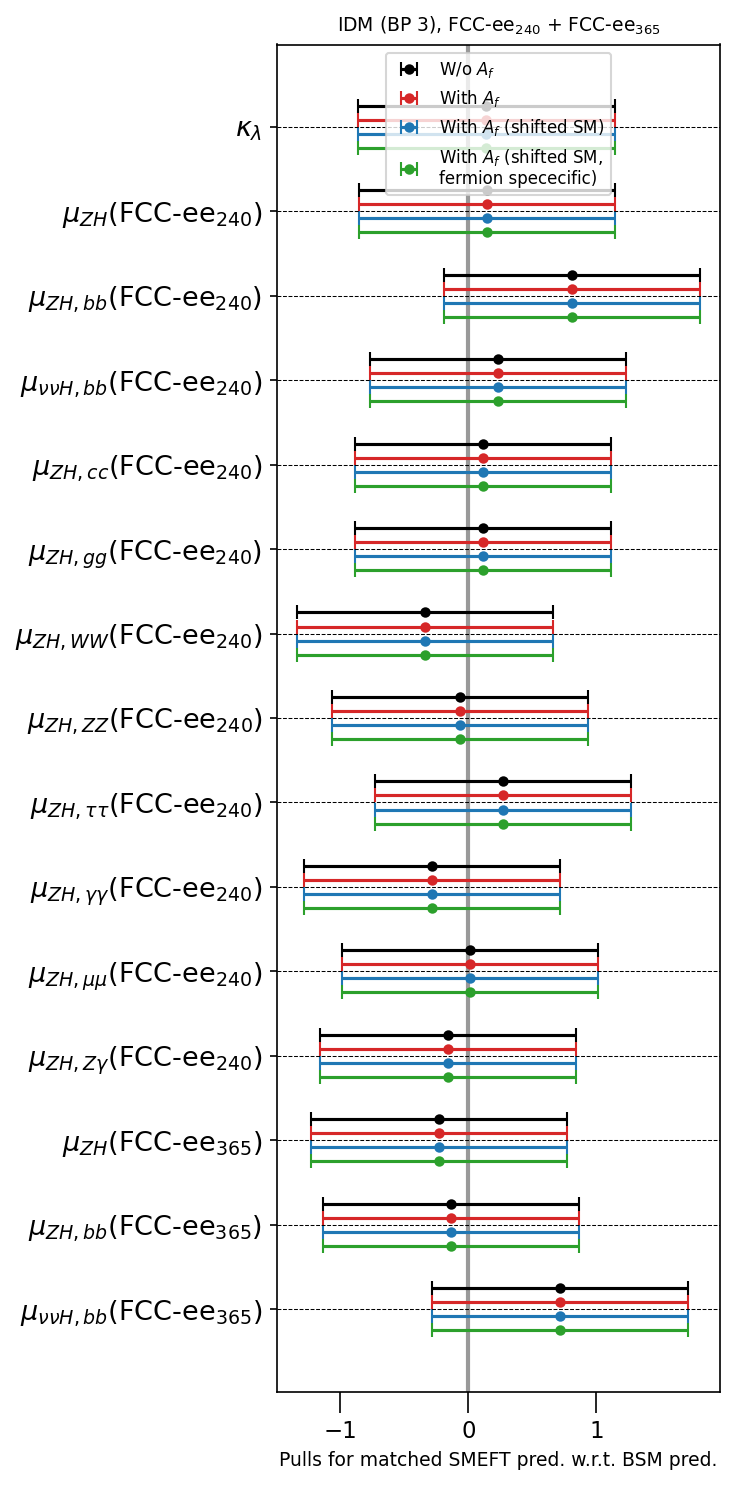

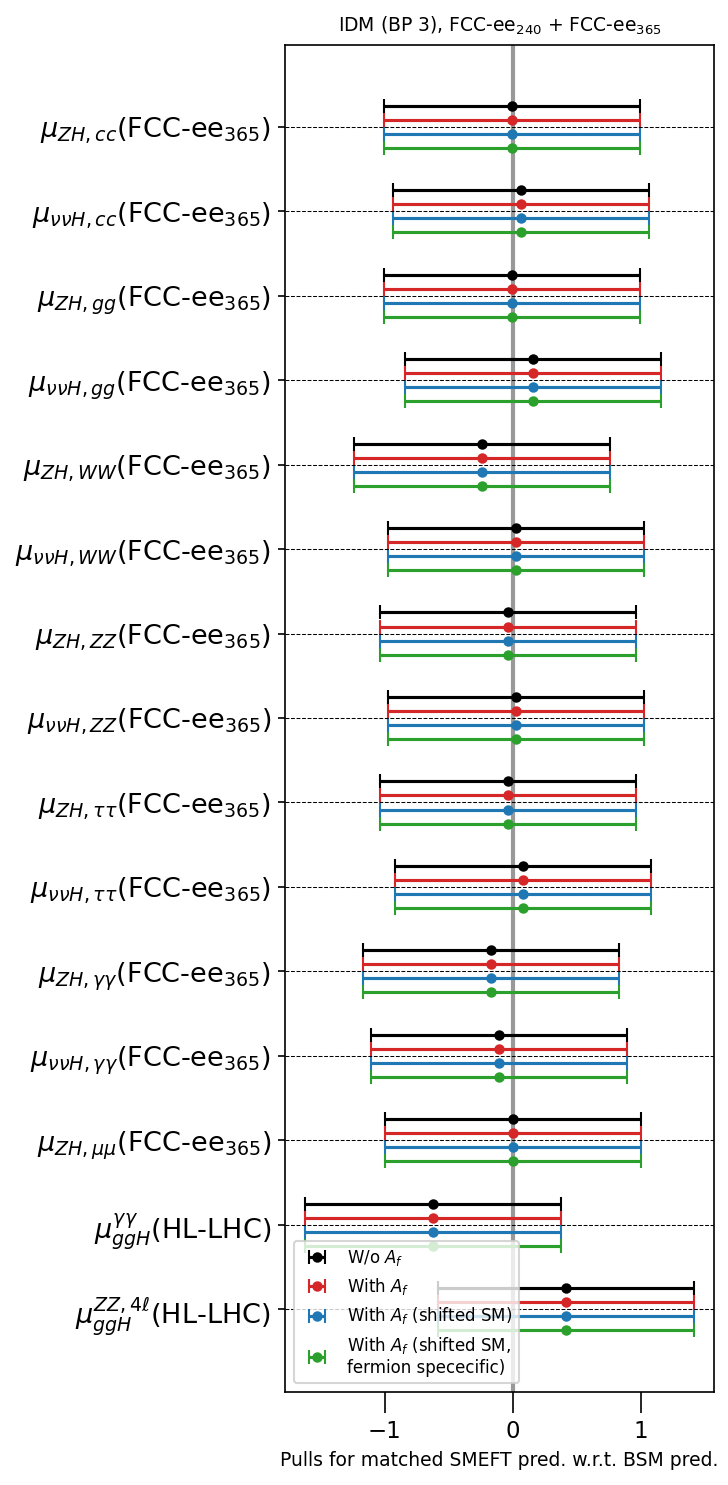

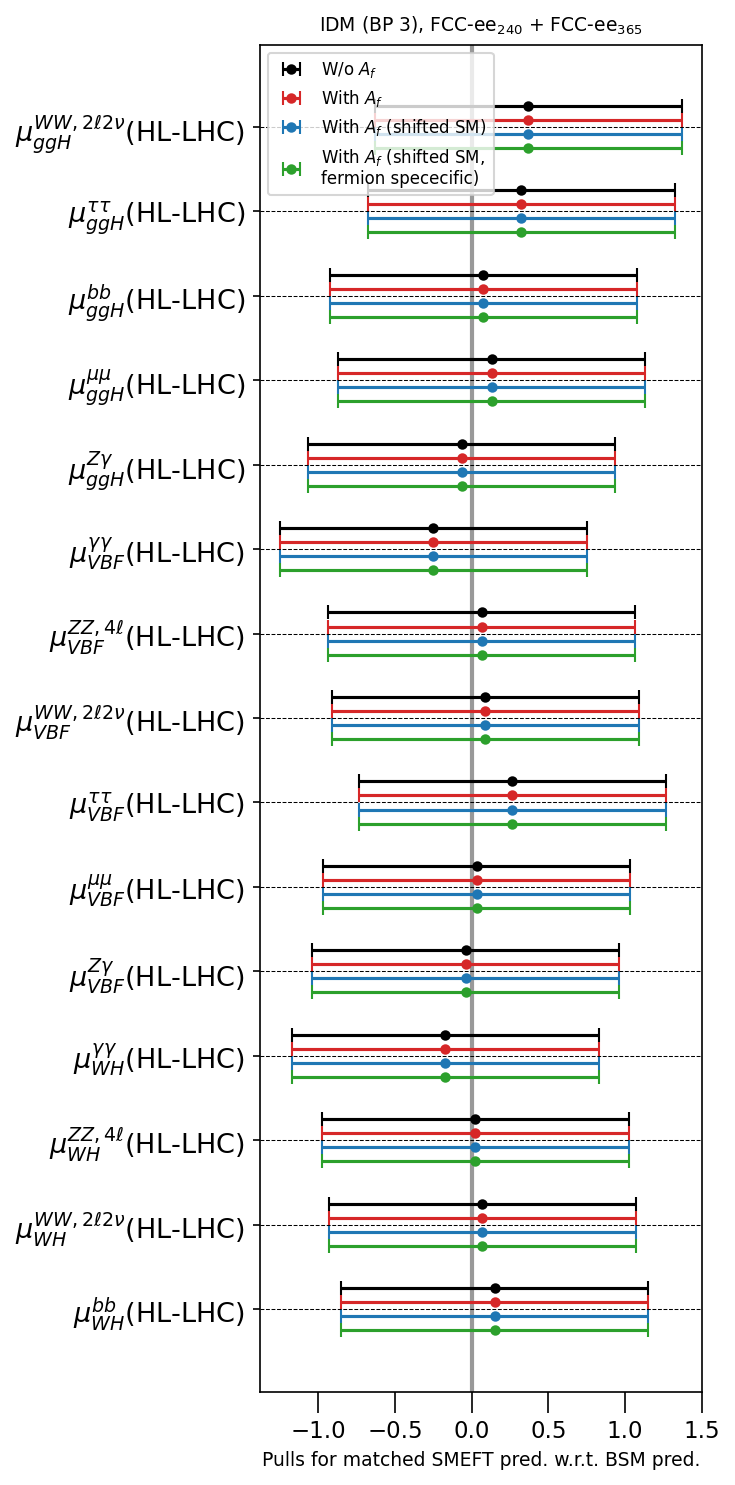

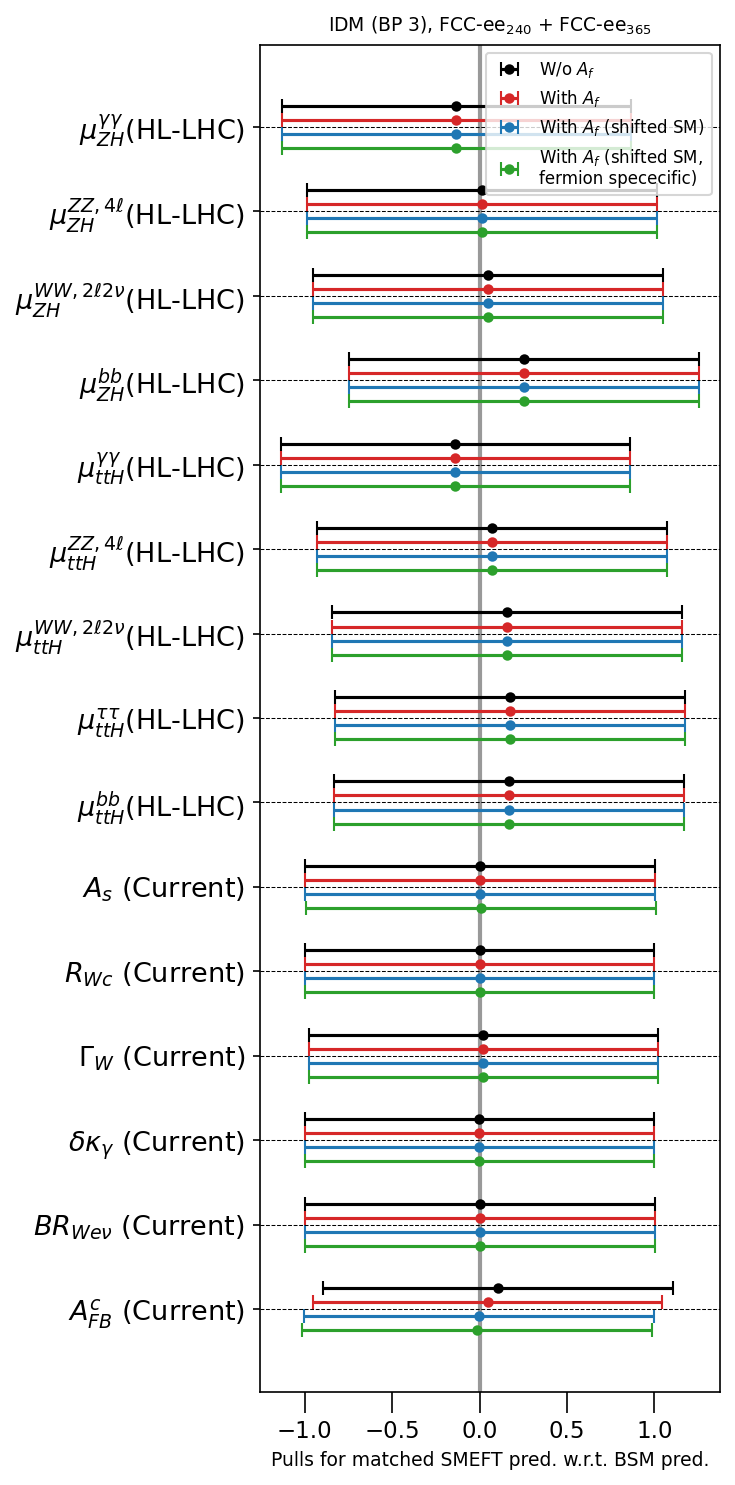

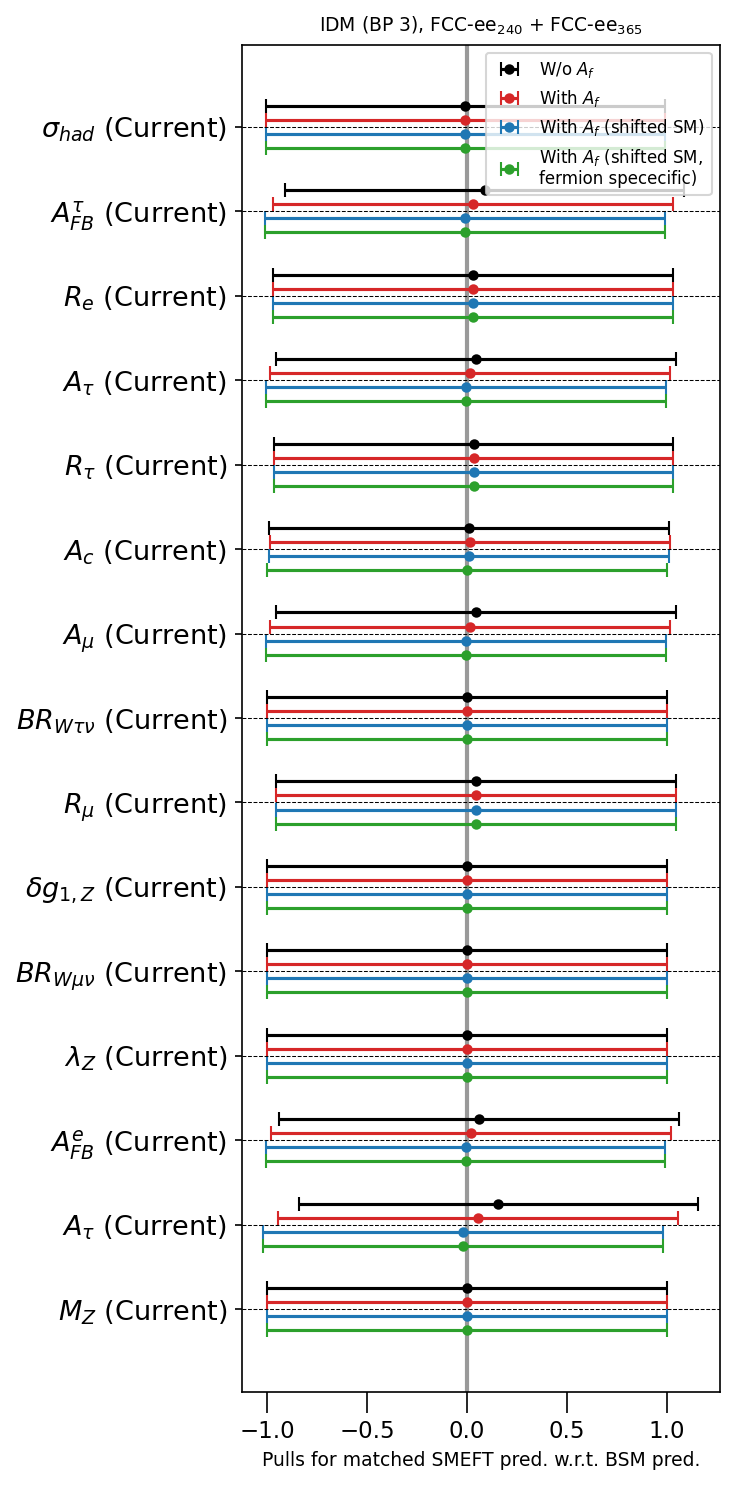

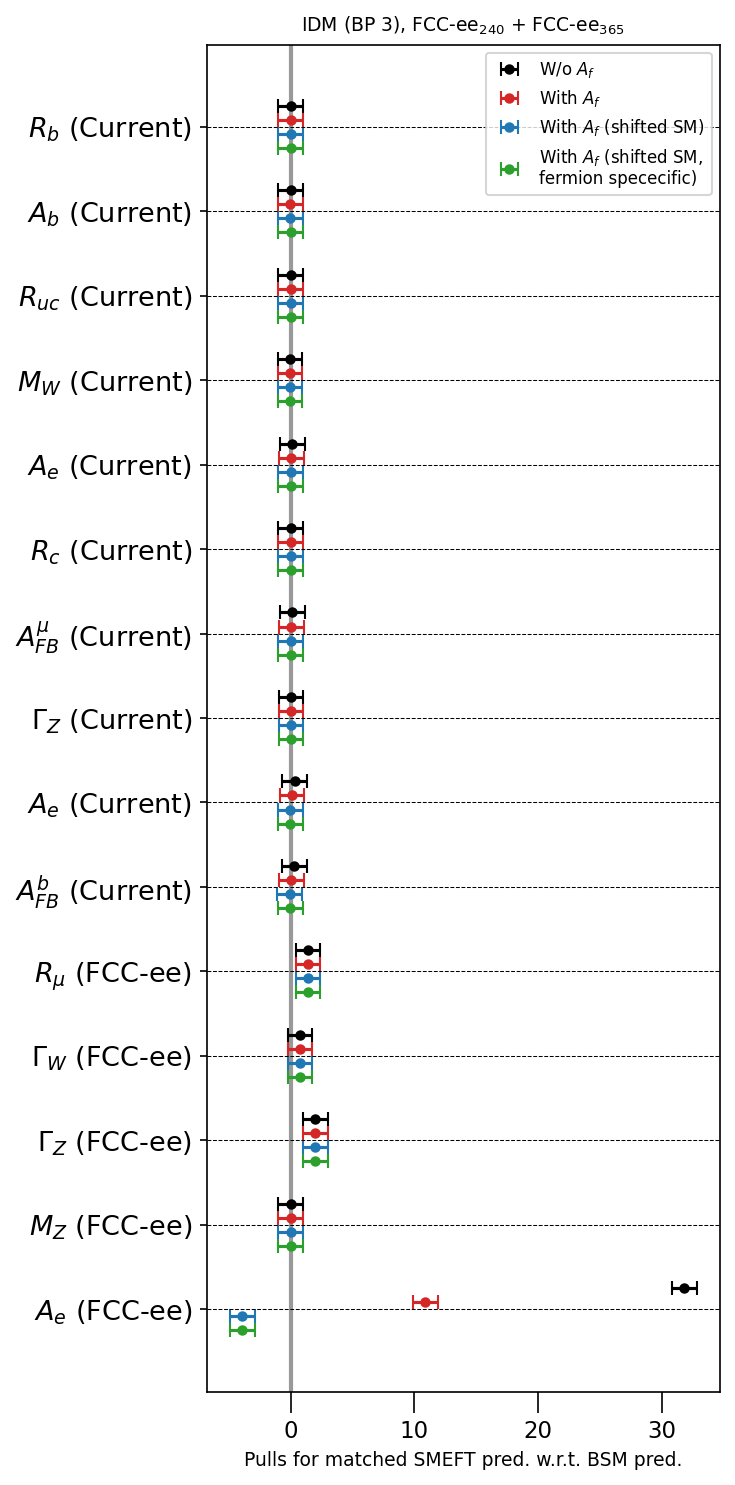

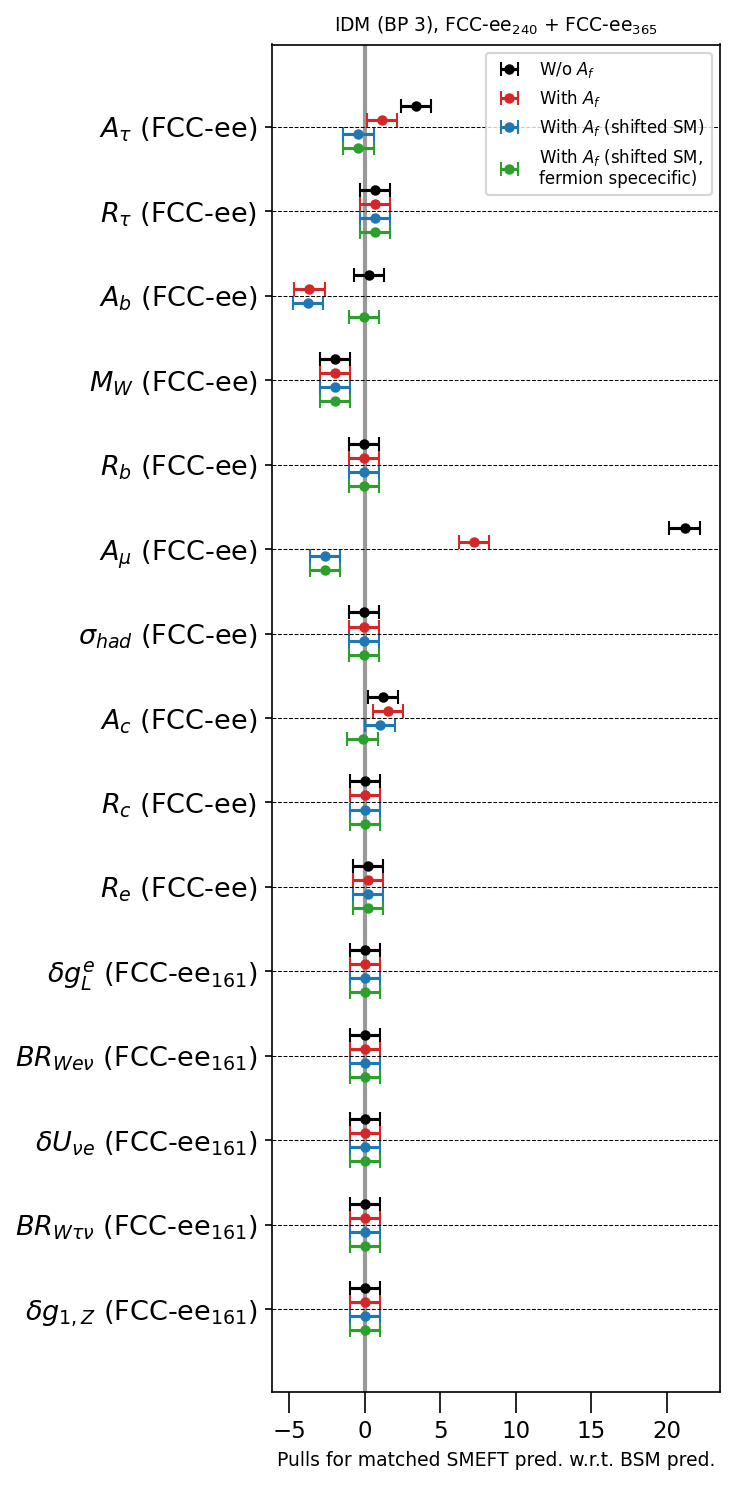

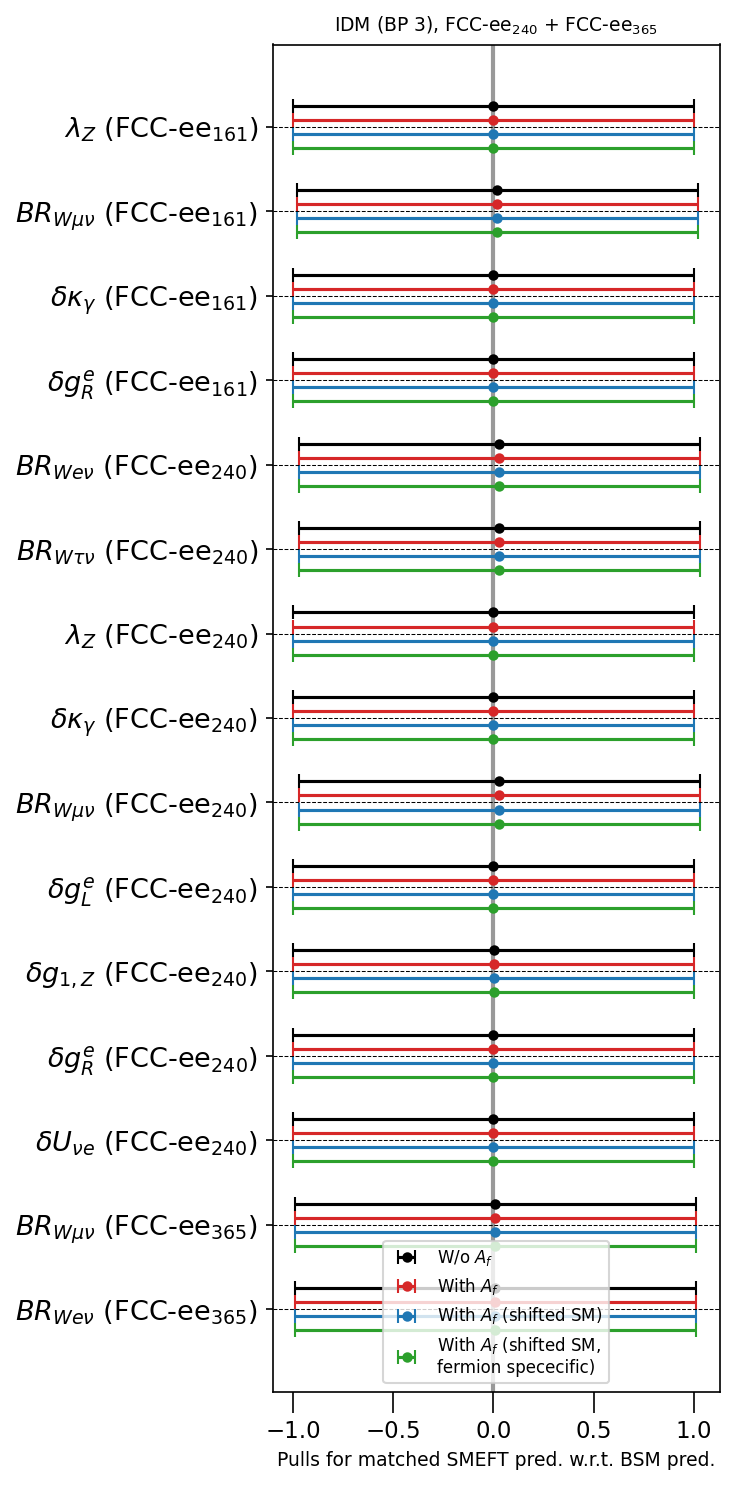

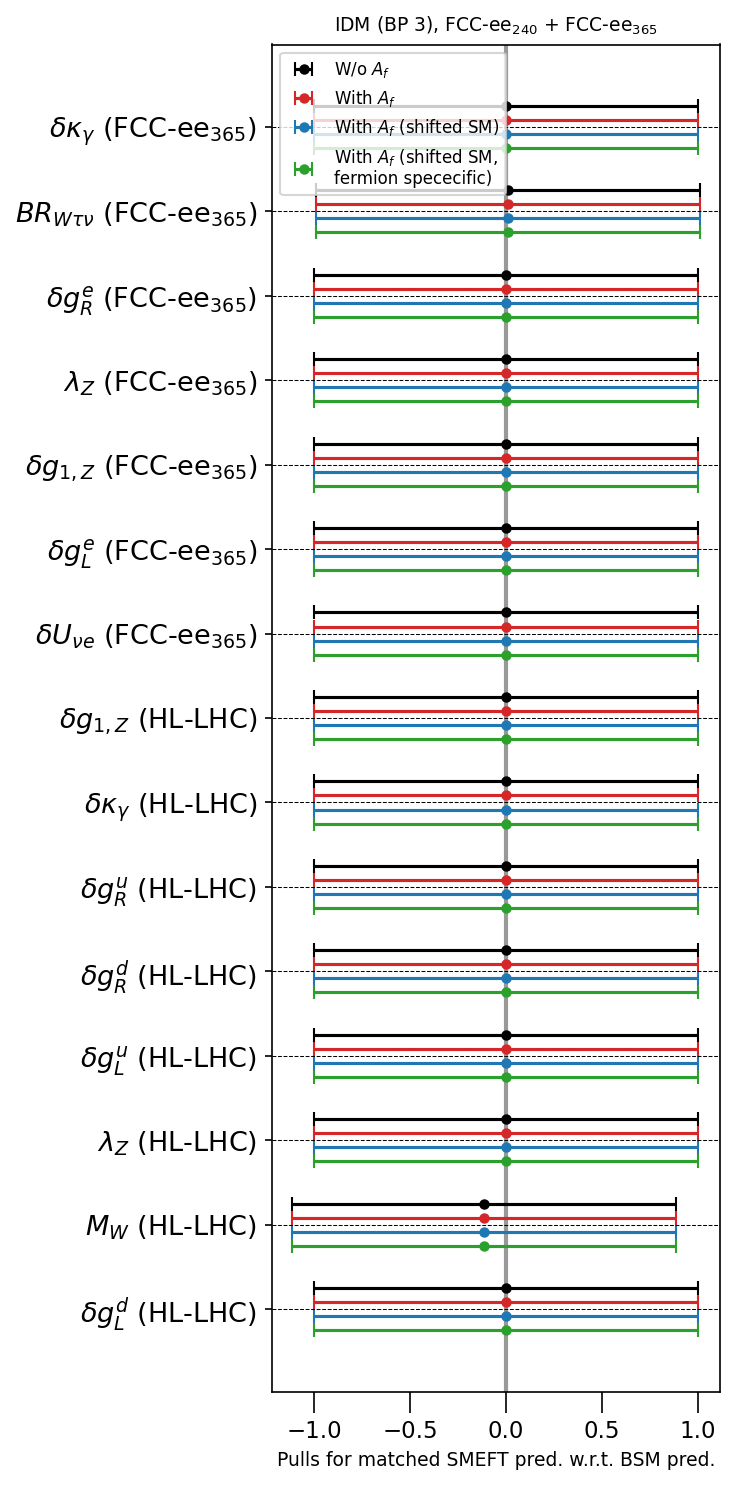

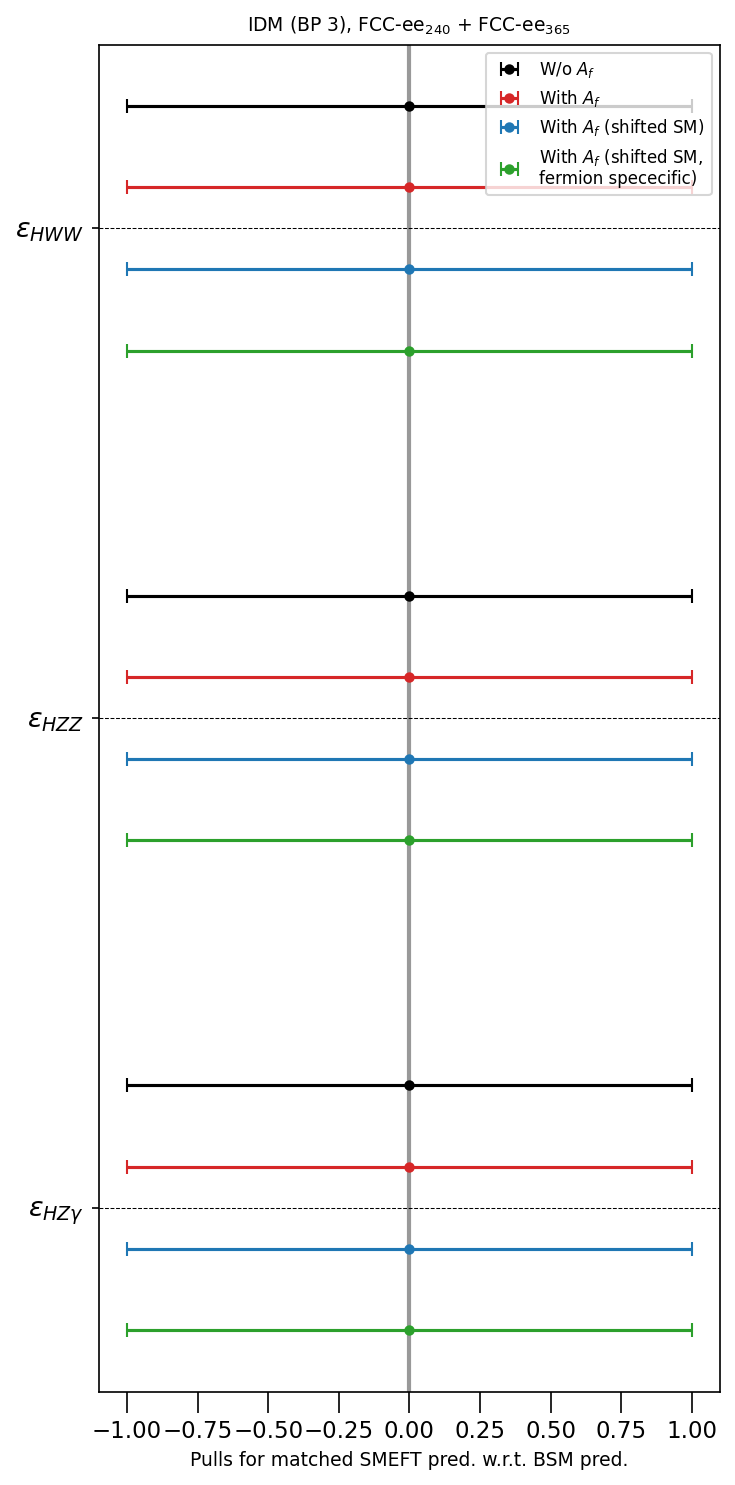

In [18]:
from fit_utils.parser import read_configuration_files, observable_order, align_observables, find_tex_label_par

working_dir = "../different_BPs"
# results_dir = "fits_small_priors_strict"
# BPs = ["Config_Files", ]
# specs = ['fits_small_priors_strict', ]
# model_specs = {"." : specs}
scenarios = model_specs.keys()
file_suffix = "_all"
x_range_min = None
x_range_max = None

nvar_per_plot=15
figsize=(5, 10)
legend_loc="best"
log_scale=False

plot_titles = { 
    BP : {
        scenario : ""
        for scenario in scenarios
    } 
    for BP in BPs
}

subprocess.run(["mkdir", "-p", f"./comparison_plots/results_{results_dir}"])
pullplots.generate_pull_plots_obs(
    BPs,
    model_specs,
    working_dir,
    results_dir,
    model_specs_labels=model_specs_labels,
    plot_titles=plot_titles_bps,
    model="IDM",
    only_obs=None,
    skip_obs=None,
    colors=colors_specs,
    show_plots=True,
    nvar_per_plot=nvar_per_plot,
    only_higgs_fccee_obs=False,
    compare_with_SM=False,
    WC_list_for_prediction_pulls=None,
    matched_predictions_vs_BSM=True,
    BP_lambdas=BP_lambdas,
    figsize=figsize,
    legend_loc=legend_loc,
    file_suffix=file_suffix,
    save_fig=True,
)